# EDA: Dataset Resep "Food.com - Recipes and Reviews"

## SUMMARY

Menjaga kesehatan di tengah kesibukan harian merupakan tantangan yang umum dihadapi masyarakat modern. Keterbatasan waktu, pengetahuan, serta akses terhadap tenaga ahli menyebabkan banyak individu kesulitan menentukan pola hidup sehat yang sesuai dengan kebutuhan personal. Informasi kesehatan yang tersedia umumnya bersifat umum dan kurang terpersonalisasi, sehingga sulit diterapkan secara konsisten dalam kehidupan sehari-hari.

Permasalahan utama yang diangkat dalam proyek ini adalah belum tersedianya platform yang mampu memberikan rekomendasi gaya hidup sehat secara otomatis dan personal berdasarkan profil kesehatan serta kebiasaan individu. Target pengguna adalah individu yang memiliki motivasi untuk hidup sehat, namun mengalami kesulitan dalam menentukan pola makan dan aktivitas fisik yang tepat.

Untuk menjawab permasalahan tersebut, dikembangkan HealthPlan, sebuah platform berbasis web yang berfungsi sebagai asisten personal dalam mengelola gaya hidup sehat. Pada tahap awal (onboarding), pengguna menginput data terkait profil kesehatan, pola makan, aktivitas fisik, serta tujuan kesehatan. Data tersebut kemudian diolah menggunakan pendekatan deep learning untuk menghasilkan rekomendasi harian yang dipersonalisasi, meliputi menu makanan, jadwal aktivitas, serta kebiasaan sehat.


Untuk mendukung proses pengembangan aplikasi ini, kami melakukan riset mengenai berbagai sumber daya yang akan dimanfaatkan oleh aplikasi. Salah satunya yaitu data resep makanan yang sehat dan bermanfaat, yang bisa direkomendasikan bagi pengguna. Dengan itu, kami melakukan proses pencarian dan pengumpulan data, hingga kami memilih untuk menggunakan dataset dari Kaggle, sebuah platform situs berbagi data.

Dataset Resep: https://www.kaggle.com/datasets/irkaal/foodcom-recipes-and-reviews?select=recipes.csv

*"The recipes dataset contains 522,517 recipes from 312 different categories. This dataset provides information about each recipe like cooking times, servings, ingredients, nutrition, instructions, and more.
The reviews dataset contains 1,401,982 reviews from 271,907 different users. This dataset provides information about the author, rating, review text, and more."*

## BUSINESS QUESTIONS

Dengan itu, ada beberapa pertanyaan bisnis yang kami rumuskan, yaitu:
1. Berapa banyak resep makanan yang memenuhi standar AKG (Minimal 25% kebutuhan kalori harian, 500 kkal per porsi), yang bisa dimasak dalam waktu kurang dari 1 jam ?
2. Resep sehat apa yang paling sesuai direkomendasikan bagi pengguna untuk menghilangkan berat badan berdasarkan target kalori 500 kkal per meal?
3. Berapa banyak resep yang mengandung bahan yang termasuk risiko alergi bagi pengguna, yakni telur, susu, gluten, kedelai, kacang tanah dan seafood?
4. Apakah ada korelasi signifikan antara waktu persiapan dan waktu memasak?
5. Berapa banyak resep yang dapat dikategorikan kesehatannya ke dalam kategori Healthy, Moderate, Unhealthy, berdasarkan kandungan nutrisinya?

# DATA WRANGLING
Data Wrangling adalah proses mengubah data mentah menjadi format yang terstruktur dan siap digunakan. Proses ini mencakup menjadi tiga, yaitu pengumpulan data, penilaian data, dan pembersihan data. Hal ini penting dilakukan untuk proses machine learning.

#### Import File untuk Colab

Untuk proses EDA, kita akan menggunakan Google Colab. Google Colab memungkinkan pengguna menjalankan komputasi yang berat dengan efisien, menghemat sumber daya dan mempercepat proses berjalannya EDA. Karena Google Colab berada di satu platform dengan Google, maka kita bisa memanfaatkan Google Drive untuk menghubungkan dengan dataset yang kita peroleh.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

## GATHERING DATA

Tahap pengumpulan data adalah tahap pengambilan informasi dari sumber relevan untuk menjawab pertanyaan bisnis. Dalam kasus ini, kelompok kami memilih untuk menggunakan dataset resep makanan yang ada dalam food.com yang tersedia dari kaggle.com, karena memiliki kolom-kolom yang dibutuhkan.

### Mengimpor dataset dari Google Drive

In [ ]:
# Loading dataset
recipe_df = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/recipes.csv')

recipe_df.head()

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09T21:46:00Z,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,39,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and..."
2,40,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05T19:52:00Z,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,41,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03T14:54:00Z,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"c(""Drain the tofu, carefully squeezing out exc..."
4,42,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19T06:19:00Z,Make and share this Cabbage Soup recipe from F...,"""https://img.sndimg.com/food/image/upload/w_55...",...,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,NaN,"c(""Mix everything together and bring to a boil..."


## ASSESSING DATA


### Melihat Ukuran Data

Langkah pertama dalam penilaian data adalah memeriksa dimensi dataset, yaitu jumlah baris (observasi) dan kolom (fitur) yang tersedia. Informasi ini memberikan gambaran awal tentang skala dataset yang akan diproses.

Untuk dataset resep Food.com, pemeriksaan ukuran data penting dilakukan sebelum memulai proses pembersihan, karena dataset asli mengandung lebih dari 500 ribu resep. Mengetahui jumlah data sejak awal membantu memperkirakan kebutuhan komputasi dan memutuskan apakah diperlukan sampling atau tidak dalam proses eksplorasi selanjutnya.

In [ ]:
# Melihat ukuran data
recipe_df.shape

(522517, 28)

### Melihat info data

Pemeriksaan informasi umum dataset dilakukan untuk mengetahui nama setiap kolom, jumlah nilai non-null, dan tipe data masing-masing kolom. Langkah ini sangat penting untuk mengidentifikasi kolom mana saja yang memiliki nilai kosong serta kolom bertipe object yang mungkin perlu dikonversi sebelum dianalisis lebih lanjut.

Pada dataset resep ini, beberapa kolom seperti waktu memasak (`CookTime`, `PrepTime`, `TotalTime`) disimpan dalam format string ISO 8601, sedangkan kolom nutrisi seharusnya bertipe numerik. Pemeriksaan tipe data di tahap awal ini memandu langkah-langkah pembersihan yang perlu dilakukan selanjutnya.

In [ ]:
# Melihat info umum
recipe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522517 entries, 0 to 522516
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    522517 non-null  int64  
 1   Name                        522517 non-null  object 
 2   AuthorId                    522517 non-null  int64  
 3   AuthorName                  522517 non-null  object 
 4   CookTime                    439972 non-null  object 
 5   PrepTime                    522517 non-null  object 
 6   TotalTime                   522517 non-null  object 
 7   DatePublished               522517 non-null  object 
 8   Description                 522512 non-null  object 
 9   Images                      522516 non-null  object 
 10  RecipeCategory              521766 non-null  object 
 11  Keywords                    505280 non-null  object 
 12  RecipeIngredientQuantities  522514 non-null  object 
 13  RecipeIngredie

### Melihat statistik deskriptif

Statistik deskriptif digunakan untuk memperoleh gambaran awal tentang sebaran nilai pada setiap kolom numerik, mencakup nilai minimum, maksimum, rata-rata, median, dan kuartil. Analisis ini membantu mendeteksi potensi anomali seperti nilai negatif pada kolom nutrisi, nilai kalori yang tidak realistis, atau rentang waktu memasak yang terlalu ekstrem.

Hasil dari tahap ini menjadi acuan untuk menentukan ambang batas yang wajar saat melakukan filtering data pada tahap cleaning, serta mengidentifikasi fitur yang memerlukan normalisasi sebelum digunakan dalam analisis lebih lanjut.

In [ ]:
# Melihat statistik deskriptif
recipe_df.describe()

,RecipeId,AuthorId,AggregatedRating,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings
count,522517.000000,5.225170e+05,269294.000000,275028.000000,522517.000000,522517.000000,522517.000000,522517.000000,5.225170e+05,522517.000000,522517.000000,522517.000000,522517.000000,339606.000000
mean,271821.436970,4.572585e+07,4.632014,5.227784,484.438580,24.614922,9.559457,86.487003,7.672639e+02,49.089092,3.843242,21.878254,17.469510,8.606191
std,155495.878422,2.929714e+08,0.641934,20.381347,1397.116649,111.485798,46.622621,301.987009,4.203621e+03,180.822062,8.603163,142.620191,40.128837,114.319809
min,38.000000,2.700000e+01,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000
25%,137206.000000,6.947400e+04,4.500000,1.000000,174.200000,5.600000,1.500000,3.800000,1.233000e+02,12.800000,0.800000,2.500000,3.500000,4.000000
50%,271758.000000,2.389370e+05,5.000000,2.000000,317.100000,13.800000,4.700000,42.600000,3.533000e+02,28.200000,2.200000,6.400000,9.100000,6.000000
75%,406145.000000,5.658280e+05,5.000000,4.000000,529.100000,27.400000,10.800000,107.900000,7.922000e+02,51.100000,4.600000,17.900000,25.000000,8.000000
max,541383.000000,2.002886e+09,5.000000,3063.000000,612854.600000,64368.100000,26740.600000,130456.400000,1.246921e+06,108294.600000,3012.000000,90682.300000,18396.200000,32767.000000


### Melihat nilai kosong (null value)
Identifikasi nilai kosong dilakukan untuk mengetahui kolom mana saja yang memiliki data tidak lengkap dan seberapa besar proporsinya. Nilai kosong yang tidak ditangani dapat menyebabkan error pada saat analisis atau menghasilkan kesimpulan yang bias.

Pada dataset resep ini, kolom seperti deskripsi resep, gambar, dan instruksi memasak diperkirakan memiliki banyak nilai kosong karena tidak semua resep mencantumkan informasi tersebut secara lengkap. Hasil pemeriksaan ini akan menentukan strategi penanganan yang tepat — apakah perlu diisi dengan nilai default, median, atau dihapus sepenuhnya.

In [ ]:
# Identifikasi nilai kosong (missing value)
recipe_df.isnull().sum()

,0
RecipeId,0
Name,0
AuthorId,0
AuthorName,0
CookTime,82545
PrepTime,0
TotalTime,0
DatePublished,0
Description,5
Images,1


### Melihat Nilai Duplikat

Pemeriksaan nilai duplikat bertujuan untuk memastikan tidak ada resep yang tercatat lebih dari satu kali dalam dataset. Data duplikat dapat memengaruhi hasil analisis distribusi dan menyebabkan bias pada sistem rekomendasi, karena resep yang sama bisa muncul berulang kali dalam hasil rekomendasi kepada pengguna.

Pada dataset Food.com yang bersumber dari platform berbagi resep, duplikasi bisa terjadi jika pengguna yang berbeda mengunggah resep dengan nama yang sama, atau jika terdapat kesalahan pada proses pengumpulan data dari Kaggle.

In [ ]:
# Identifikasi nilai duplikat
recipe_df.duplicated().sum()

np.int64(0)

### Melihat Nilai Unik di Kolom Kategorikal

Pemeriksaan nilai unik pada kolom bertipe object dilakukan untuk memahami keragaman kategori yang ada dalam dataset. Informasi ini penting untuk mengidentifikasi apakah terdapat inkonsistensi penulisan, seperti perbedaan kapitalisasi atau spasi, yang dapat membuat kategori yang seharusnya sama menjadi terbaca berbeda oleh sistem.

Untuk dataset resep ini, kolom seperti `RecipeCategory` dan `Keywords` memiliki jumlah nilai unik yang sangat besar. Memahami keragaman ini sejak awal membantu menentukan apakah diperlukan standardisasi atau pengelompokan ulang kategori sebelum digunakan dalam sistem rekomendasi HealthPlan.

In [ ]:
# Identifikasi nilai unik di setiap kolom kategorikal
recipe_df.select_dtypes(include=['object']).nunique()

,0
Name,438188
AuthorName,56793
CookTime,490
PrepTime,318
TotalTime,1240
DatePublished,245540
Description,492838
Images,165889
RecipeCategory,311
Keywords,216569


## CLEANING DATA

### Filtering Data Berdasarkan Nutrisi

Tahap ini melakukan dua hal sekaligus: pertama, mengonversi seluruh kolom nutrisi ke tipe numerik agar dapat diproses secara matematis; kedua, menormalkan nilai nutrisi menjadi per porsi dengan membagi setiap kolom nutrisi dengan `RecipeServings`. Normalisasi ini penting agar perbandingan antar resep bersifat adil — resep dengan 10 porsi tidak tampak jauh lebih tinggi kandungan nutrisinya dibanding resep dengan 1 porsi.

Setelah normalisasi, dibuat `healthy_df` dengan memfilter resep berdasarkan ambang batas nutrisi yang mengacu pada standar gizi umum: kalori di bawah 600 kkal, lemak jenuh di bawah 7g, sodium di bawah 700mg, dan sebagainya. Statistik deskriptif `healthy_df.describe()` ditampilkan di akhir cell untuk memverifikasi bahwa seluruh nilai pada dataset hasil filter sudah berada dalam batas yang telah ditetapkan, sekaligus memberikan gambaran profil nutrisi rata-rata resep yang akan direkomendasikan kepada pengguna HealthPlan.

In [ ]:
nutrition_cols = [
    'Calories',
    'FatContent',
    'SaturatedFatContent',
    'CholesterolContent',
    'SodiumContent',
    'CarbohydrateContent',
    'FiberContent',
    'SugarContent',
    'ProteinContent'
]

# Ubah ke numerik
for col in nutrition_cols:
    recipe_df[col] = pd.to_numeric(recipe_df[col], errors='coerce')

In [ ]:
# Hapus serving null
recipe_df = recipe_df[recipe_df['RecipeServings'].notna()]

# Hapus serving <= 0
recipe_df = recipe_df[recipe_df['RecipeServings'] > 0]

# Ubah nutrisi menjadi per serving
for col in nutrition_cols:
    recipe_df[col] = recipe_df[col] / recipe_df['RecipeServings']

# Set serving menjadi 1
recipe_df['RecipeServings'] = 1

In [ ]:
recipe_df[['Name', 'Calories', 'RecipeServings']].head()

,Name,Calories,RecipeServings
0,Low-Fat Berry Blue Frozen Dessert,42.725000,1
1,Biryani,185.116667,1
2,Best Lemonade,77.775000,1
3,Carina's Tofu-Vegetable Kebabs,268.050000,1
4,Cabbage Soup,25.900000,1


In [ ]:
# Memfilter data untuk memilah resep yang tergolong "sehat"
healthy_df = recipe_df[
    (recipe_df['Calories'] < 600) &
    (recipe_df['CarbohydrateContent'] <= 114) &
    (recipe_df['FatContent'] < 25) &
    (recipe_df['SaturatedFatContent'] < 7) &
    (recipe_df['SugarContent'] < 10) &
    (recipe_df['CholesterolContent'] < 100) &
    (recipe_df['SodiumContent'] < 700)
].copy()

print("Jumlah data sebelum filtering :", len(recipe_df))
print("Jumlah data sesudah filtering :", len(healthy_df))
print("Jumlah data yang terhapus :", len(recipe_df) - len(healthy_df))

healthy_df.describe()

Jumlah data sebelum filtering : 339606
Jumlah data sesudah filtering : 304374
Jumlah data yang terhapus : 35232


,RecipeId,AuthorId,AggregatedRating,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings
count,304374.000000,3.043740e+05,154932.000000,158067.000000,304374.000000,304374.000000,304374.000000,304374.000000,304374.000000,304374.000000,304374.000000,304374.000000,304374.000000,304374.0
mean,278818.135159,4.933145e+07,4.626426,5.136645,60.521673,2.884657,1.047543,11.459707,88.325960,5.432280,0.597126,1.557938,2.984783,1.0
std,154829.516569,3.037700e+08,0.639834,21.058361,57.079586,3.237399,1.248589,15.435732,110.177208,6.310007,0.961817,1.864299,3.874545,0.0
min,38.000000,2.700000e+01,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,147026.500000,8.099800e+04,4.500000,1.000000,19.875000,0.604167,0.166667,0.352778,13.537500,1.500000,0.090000,0.316667,0.375000,1.0
50%,281115.000000,2.550105e+05,5.000000,2.000000,44.575000,1.816667,0.583333,5.241667,46.425000,3.566667,0.300000,0.850000,1.325000,1.0
75%,412709.750000,5.708040e+05,5.000000,4.000000,83.175000,3.975000,1.462500,17.100000,121.900000,7.175000,0.737500,2.050000,4.366667,1.0
max,541379.000000,2.002882e+09,5.000000,3063.000000,599.450000,24.983333,6.983333,99.975000,699.750000,114.000000,61.700000,9.987500,90.200000,1.0


### Membuat filter kolom yang berguna untuk healthy_df

In [ ]:
# Hapus kolom selain kolom nutrisi pada healthy_df
used_cols = [
    'Name',
    'Calories',
    'FatContent',
    'SaturatedFatContent',
    'CholesterolContent',
    'SodiumContent',
    'CarbohydrateContent',
    'FiberContent',
    'SugarContent',
    'ProteinContent'
]

healthy_df = healthy_df.dropna(subset=used_cols)

In [ ]:
# Hapus baris yang memiliki calori tinggi dan nutrisi tidak sehat
recipe_df = recipe_df[
    (recipe_df['Calories'] < 700) &
    (recipe_df['CarbohydrateContent'] <= 114) &
    (recipe_df['FatContent'] < 25) &
    (recipe_df['SaturatedFatContent'] < 7) &
    (recipe_df['SugarContent'] < 10) &
    (recipe_df['CholesterolContent'] < 100) &
    (recipe_df['SodiumContent'] < 700)
]

print(len(recipe_df))

304407


In [ ]:
recipe_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304407 entries, 0 to 522512
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    304407 non-null  int64  
 1   Name                        304407 non-null  object 
 2   AuthorId                    304407 non-null  int64  
 3   AuthorName                  304407 non-null  object 
 4   CookTime                    261259 non-null  object 
 5   PrepTime                    304407 non-null  object 
 6   TotalTime                   304407 non-null  object 
 7   DatePublished               304407 non-null  object 
 8   Description                 304406 non-null  object 
 9   Images                      304407 non-null  object 
 10  RecipeCategory              303979 non-null  object 
 11  Keywords                    293884 non-null  object 
 12  RecipeIngredientQuantities  304406 non-null  object 
 13  RecipeIngredientPar

### Menangani nilai kosong (missing value)

In [ ]:
# Jumlah missing value per kolom
recipe_df.isnull().sum()

(recipe_df.isnull().sum() / len(recipe_df)) * 100

recipe_df = recipe_df.dropna(how='all')

nutrition_cols = [
    'Calories',
    'FatContent',
    'SaturatedFatContent',
    'CholesterolContent',
    'SodiumContent',
    'CarbohydrateContent',
    'FiberContent',
    'SugarContent',
    'ProteinContent'
]

for col in nutrition_cols:
    recipe_df[col] = recipe_df[col].fillna(recipe_df[col].median())

In [ ]:
# Kolom text/object
text_cols = [
    'CookTime',
    'PrepTime',
    'TotalTime',
    'Description',
    'Images',
    'RecipeCategory',
    'Keywords',
    'RecipeIngredientQuantities',
    'RecipeIngredientParts',
    'RecipeInstructions'
]

# Isi missing value kolom text dengan string kosong
for col in text_cols:
    recipe_df[col] = recipe_df[col].fillna('')

# isi missing RecipeYield dengan 'Unknown'
recipe_df['RecipeYield'] = recipe_df['RecipeYield'].fillna('Unknown')

# Handle numeric missing

nutrition_cols = [
    'Calories',
    'FatContent',
    'SaturatedFatContent',
    'CholesterolContent',
    'SodiumContent',
    'CarbohydrateContent',
    'FiberContent',
    'SugarContent',
    'ProteinContent'
]

# isi missing value numerik dengan median
for col in nutrition_cols:
    recipe_df[col] = recipe_df[col].fillna(recipe_df[col].median())

In [ ]:
recipe_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304407 entries, 0 to 522512
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    304407 non-null  int64  
 1   Name                        304407 non-null  object 
 2   AuthorId                    304407 non-null  int64  
 3   AuthorName                  304407 non-null  object 
 4   CookTime                    304407 non-null  object 
 5   PrepTime                    304407 non-null  object 
 6   TotalTime                   304407 non-null  object 
 7   DatePublished               304407 non-null  object 
 8   Description                 304407 non-null  object 
 9   Images                      304407 non-null  object 
 10  RecipeCategory              304407 non-null  object 
 11  Keywords                    304407 non-null  object 
 12  RecipeIngredientQuantities  304407 non-null  object 
 13  RecipeIngredientPar

### Menangani data duplikat

In [ ]:
# Hapus duplikat berdasarkan nama resep
recipe_df = recipe_df.drop_duplicates(subset=['Name'])

# Reset index
recipe_df = recipe_df.reset_index(drop=True)

recipe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264850 entries, 0 to 264849
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    264850 non-null  int64  
 1   Name                        264850 non-null  object 
 2   AuthorId                    264850 non-null  int64  
 3   AuthorName                  264850 non-null  object 
 4   CookTime                    264850 non-null  object 
 5   PrepTime                    264850 non-null  object 
 6   TotalTime                   264850 non-null  object 
 7   DatePublished               264850 non-null  object 
 8   Description                 264850 non-null  object 
 9   Images                      264850 non-null  object 
 10  RecipeCategory              264850 non-null  object 
 11  Keywords                    264850 non-null  object 
 12  RecipeIngredientQuantities  264850 non-null  object 
 13  RecipeIngredie

In [ ]:
recipe_df.duplicated().sum()

np.int64(0)

### Convert ISO ke menit

Pada bagian ini, kita akan mengonversi durasi waktu yang disimpan dalam format ISO 8601 (contohnya, PT2H30M menjadi 2 jam 30 menit) menjadi total menit. Ini dilakukan agar waktu masak resep dapat lebih mudah dibaca dan diproses nantinya.

In [ ]:
def convert_iso_to_minutes(duration):

    if pd.isna(duration) or duration == '':
        return None

    hours = 0
    minutes = 0

    h = re.search(r'(\d+)H', str(duration))
    m = re.search(r'(\d+)M', str(duration))

    if h:
        hours = int(h.group(1))

    if m:
        minutes = int(m.group(1))

    return hours * 60 + minutes

In [ ]:
recipe_df['TotalTimeMinutes'] = recipe_df['TotalTime'].apply(convert_iso_to_minutes)

recipe_df['CookTimeMinutes'] = recipe_df['CookTime'].apply(convert_iso_to_minutes)

recipe_df['PrepTimeMinutes'] = recipe_df['PrepTime'].apply(convert_iso_to_minutes)

In [ ]:
recipe_df[['TotalTimeMinutes', 'CookTimeMinutes', 'PrepTimeMinutes']].head()

,TotalTimeMinutes,CookTimeMinutes,PrepTimeMinutes
0,1485,1440.0,45
1,265,25.0,240
2,50,30.0,20
3,140,120.0,20
4,80,50.0,30


In [ ]:
recipe_df['CookTimeMinutes'] = recipe_df['CookTimeMinutes'].fillna(0)

# Verify the change
recipe_df[['Name', 'CookTime', 'CookTimeMinutes']].head()

,Name,CookTime,CookTimeMinutes
0,Low-Fat Berry Blue Frozen Dessert,PT24H,1440.0
1,Biryani,PT25M,25.0
2,Cabbage Soup,PT30M,30.0
3,Best Blackbottom Pie,PT2H,120.0
4,Buttermilk Pie With Gingersnap Crumb Crust,PT50M,50.0


In [ ]:
recipe_df[['TotalTimeMinutes', 'CookTimeMinutes', 'PrepTimeMinutes']].head()

,TotalTimeMinutes,CookTimeMinutes,PrepTimeMinutes
0,1485,1440.0,45
1,265,25.0,240
2,50,30.0,20
3,140,120.0,20
4,80,50.0,30


In [ ]:
recipe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264850 entries, 0 to 264849
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    264850 non-null  int64  
 1   Name                        264850 non-null  object 
 2   AuthorId                    264850 non-null  int64  
 3   AuthorName                  264850 non-null  object 
 4   CookTime                    264850 non-null  object 
 5   PrepTime                    264850 non-null  object 
 6   TotalTime                   264850 non-null  object 
 7   DatePublished               264850 non-null  object 
 8   Description                 264850 non-null  object 
 9   Images                      264850 non-null  object 
 10  RecipeCategory              264850 non-null  object 
 11  Keywords                    264850 non-null  object 
 12  RecipeIngredientQuantities  264850 non-null  object 
 13  RecipeIngredie

### Drop kolom yang tidak digunakan sejauh ini

In [ ]:
drop_columns = [
    'AuthorId',
    'AuthorName',
    'CookTime',
    'PrepTime',
    'TotalTime',
    'DatePublished',
    'AggregatedRating',
    'ReviewCount'
]

recipe_df = recipe_df.drop(columns=drop_columns)
recipe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264850 entries, 0 to 264849
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    264850 non-null  int64  
 1   Name                        264850 non-null  object 
 2   Description                 264850 non-null  object 
 3   Images                      264850 non-null  object 
 4   RecipeCategory              264850 non-null  object 
 5   Keywords                    264850 non-null  object 
 6   RecipeIngredientQuantities  264850 non-null  object 
 7   RecipeIngredientParts       264850 non-null  object 
 8   Calories                    264850 non-null  float64
 9   FatContent                  264850 non-null  float64
 10  SaturatedFatContent         264850 non-null  float64
 11  CholesterolContent          264850 non-null  float64
 12  SodiumContent               264850 non-null  float64
 13  CarbohydrateCo

### Menangani Nilai Outlier

Penanganan outlier dilakukan menggunakan metode IQR Clipping, yaitu membatasi nilai ekstrem pada batas bawah (Q1 − 1.5×IQR) dan batas atas (Q3 + 1.5×IQR). Metode ini dipilih karena lebih toleran terhadap distribusi data yang tidak normal dibandingkan pendekatan berbasis rata-rata, dan tidak menghapus baris data sehingga ukuran dataset tetap terjaga.

Outlier pada kolom nutrisi seperti kalori, lemak, dan sodium dapat terjadi karena kesalahan input pengguna atau resep yang memang tidak representatif (misalnya resep untuk acara pesta dengan porsi sangat besar). Jika dibiarkan, nilai ekstrem ini dapat mendistorsi hasil analisis distribusi dan menurunkan kualitas rekomendasi yang dihasilkan oleh platform HealthPlan. Statistik deskriptif setelah clipping ditampilkan untuk memverifikasi bahwa nilai-nilai ekstrem sudah berhasil dibatasi.

In [ ]:
# handling outlier
numeric_cols = [
    'RecipeId',
    'Calories',
    'FatContent',
    'SaturatedFatContent',
    'CholesterolContent',
    'SodiumContent',
    'CarbohydrateContent',
    'FiberContent',
    'SugarContent',
    'ProteinContent',
    'RecipeServings',
    'TotalTimeMinutes',
    'CookTimeMinutes',
    'PrepTimeMinutes'
]

for col in numeric_cols:

    Q1 = recipe_df[col].quantile(0.25)
    Q3 = recipe_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    recipe_df[col] = recipe_df[col].clip(lower, upper)

In [ ]:
recipe_df[numeric_cols].describe()

,RecipeId,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,TotalTimeMinutes,CookTimeMinutes,PrepTimeMinutes
count,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.0,264850.000000,264850.000000,264850.000000
mean,273743.007008,58.611950,2.716309,0.973991,10.613825,80.408428,4.994482,0.504332,1.406214,2.796106,1.0,49.701826,30.210480,15.741805
std,155914.765036,49.150136,2.657970,1.027403,12.681190,85.792554,4.499421,0.532122,1.430223,3.144167,0.0,36.835173,28.549336,9.640148
min,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,139249.500000,19.833333,0.600000,0.162500,0.300000,13.233333,1.475000,0.088889,0.312500,0.375000,1.0,22.000000,10.000000,10.000000
50%,273685.500000,45.025000,1.825000,0.583333,5.166667,46.138750,3.562500,0.300000,0.850000,1.350000,1.0,40.000000,20.000000,15.000000
75%,409060.250000,84.283333,4.025000,1.472857,17.100000,122.075000,7.250000,0.750000,2.050000,4.425000,1.0,65.000000,45.000000,20.000000
max,541379.000000,180.958333,9.162500,3.438393,42.300000,285.337500,15.912500,1.741667,4.656250,10.500000,1.0,129.500000,97.500000,35.000000


### Mengupdate nama kolom

In [ ]:
recipe_df = recipe_df.rename(columns={
    "RecipeId": "recipe_id",
    "Name": "recipe_name",
    "Calories": "calories",
    "FatContent": "fat",
    "SaturatedFatContent": "saturated_fat",
    "CholesterolContent": "cholesterol",
    "SodiumContent": "sodium",
    "CarbohydrateContent": "carbs",
    "FiberContent": "fiber",
    "SugarContent": "sugar",
    "ProteinContent": "protein",
    "TotalTimeMinutes": "total_time"
})

### Menginisialisasi ulang kolom nutrition_cols

Setelah proses rename kolom dan filter akhir berdasarkan kalori, protein, dan sodium, statistik deskriptif dicetak kembali untuk memverifikasi konsistensi nilai pada seluruh fitur nutrisi. Pemeriksaan ini memastikan bahwa proses rename tidak menyebabkan pergeseran data dan bahwa nilai-nilai nutrisi masih berada dalam rentang yang wajar secara gizi.

Hasil deskriptif ini juga berfungsi sebagai dokumentasi kondisi final dataset sebelum diekspor, sehingga dapat dijadikan referensi untuk menjelaskan karakteristik data kepada reviewer atau anggota tim yang belum terlibat dalam proses pembersihan.

In [ ]:
nutrition_cols = [
    "calories",
    "fat",
    "saturated_fat",
    "cholesterol",
    "sodium",
    "carbs",
    "fiber",
    "sugar",
    "protein"
]

print(
    recipe_df[nutrition_cols]
    .describe()
)

            calories            fat  saturated_fat    cholesterol  \
count  264850.000000  264850.000000  264850.000000  264850.000000   
mean       58.611950       2.716309       0.973991      10.613825   
std        49.150136       2.657970       1.027403      12.681190   
min         0.000000       0.000000       0.000000       0.000000   
25%        19.833333       0.600000       0.162500       0.300000   
50%        45.025000       1.825000       0.583333       5.166667   
75%        84.283333       4.025000       1.472857      17.100000   
max       180.958333       9.162500       3.438393      42.300000   

              sodium          carbs          fiber          sugar  \
count  264850.000000  264850.000000  264850.000000  264850.000000   
mean       80.408428       4.994482       0.504332       1.406214   
std        85.792554       4.499421       0.532122       1.430223   
min         0.000000       0.000000       0.000000       0.000000   
25%        13.233333       1.4750

### Memfilter "calories", "protein", dan "sodium"

In [ ]:
recipe_df = recipe_df[
    (recipe_df["calories"] <= 2000) &
    (recipe_df["protein"] <= 150) &
    (recipe_df["sodium"] <= 5000)
]

In [ ]:
recipe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264850 entries, 0 to 264849
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   recipe_id                   264850 non-null  int64  
 1   recipe_name                 264850 non-null  object 
 2   Description                 264850 non-null  object 
 3   Images                      264850 non-null  object 
 4   RecipeCategory              264850 non-null  object 
 5   Keywords                    264850 non-null  object 
 6   RecipeIngredientQuantities  264850 non-null  object 
 7   RecipeIngredientParts       264850 non-null  object 
 8   calories                    264850 non-null  float64
 9   fat                         264850 non-null  float64
 10  saturated_fat               264850 non-null  float64
 11  cholesterol                 264850 non-null  float64
 12  sodium                      264850 non-null  float64
 13  carbs         

## EXPORT DATA

In [ ]:
print(recipe_df.head())

   recipe_id                                 recipe_name  \
0         38           Low-Fat Berry Blue Frozen Dessert   
1         39                                     Biryani   
2         42                                Cabbage Soup   
3         43                        Best Blackbottom Pie   
4         45  Buttermilk Pie With Gingersnap Crumb Crust   

                                         Description  \
0  Make and share this Low-Fat Berry Blue Frozen ...   
1  Make and share this Biryani recipe from Food.com.   
2  Make and share this Cabbage Soup recipe from F...   
3  Make and share this Best Blackbottom Pie recip...   
4  Make and share this Buttermilk Pie With Ginger...   

                                              Images   RecipeCategory  \
0  c("https://img.sndimg.com/food/image/upload/w_...  Frozen Desserts   
1  c("https://img.sndimg.com/food/image/upload/w_...   Chicken Breast   
2  "https://img.sndimg.com/food/image/upload/w_55...        Vegetable   
3         

In [ ]:
recipe_df.to_csv('/content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/recipes_cleaned.csv', index=False)

# EXPLORATORY DATA ANALYSIS

## Import dataset yang telah dibersihkan sebelumnya

In [ ]:
# Loading dataset
recipes_cleaned_df = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/recipes_cleaned.csv')

recipes_cleaned_df.head()

,recipe_id,recipe_name,Description,Images,RecipeCategory,Keywords,RecipeIngredientQuantities,RecipeIngredientParts,calories,fat,...,carbs,fiber,sugar,protein,RecipeServings,RecipeYield,RecipeInstructions,total_time,CookTimeMinutes,PrepTimeMinutes
0,38,Low-Fat Berry Blue Frozen Dessert,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",Frozen Desserts,"c(""Dessert"", ""Low Protein"", ""Low Cholesterol"",...","c(""4"", ""1/4"", ""1"", ""1"")","c(""blueberries"", ""granulated sugar"", ""vanilla ...",42.725000,0.6250,...,9.275000,0.9000,4.65625,0.800,1,Unknown,"c(""Toss 2 cups berries with sugar."", ""Let stan...",129.5,97.5,35
1,39,Biryani,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",Chicken Breast,"c(""Chicken Thigh & Leg"", ""Chicken"", ""Poultry"",...","c(""1"", ""4"", ""2"", ""2"", ""8"", ""1/4"", ""8"", ""1/2"", ...","c(""saffron"", ""milk"", ""hot green chili peppers""...",180.958333,9.1625,...,14.066667,1.5000,3.40000,10.500,1,Unknown,"c(""Soak saffron in warm milk for 5 minutes and...",129.5,25.0,35
2,42,Cabbage Soup,Make and share this Cabbage Soup recipe from F...,"""https://img.sndimg.com/food/image/upload/w_55...",Vegetable,"c(""Low Protein"", ""Vegan"", ""Low Cholesterol"", ""...","c(""46"", ""4"", ""1"", ""2"", ""1"")","c(""plain tomato juice"", ""cabbage"", ""onion"", ""c...",25.900000,0.1000,...,6.275000,1.2000,4.42500,1.075,1,Unknown,"c(""Mix everything together and bring to a boil...",50.0,30.0,20
3,43,Best Blackbottom Pie,Make and share this Best Blackbottom Pie recip...,character(0),Pie,"c(""Dessert"", ""Weeknight"", ""Stove Top"", ""< 4 Ho...","c(""1 1/4"", ""1/4"", ""6"", ""1/3"", ""1/4"", ""1/4"", ""2...","c(""graham cracker crumbs"", ""sugar"", ""butter"", ...",54.737500,2.4125,...,7.250000,0.2250,4.65625,0.875,1,1 9-inch pie,"c(""Graham Cracker Crust: In small bowl, combin...",129.5,97.5,20
4,45,Buttermilk Pie With Gingersnap Crumb Crust,Make and share this Buttermilk Pie With Ginger...,"""https://img.sndimg.com/food/image/upload/w_55...",Pie,"c(""Dessert"", ""Healthy"", ""Weeknight"", ""Oven"", ""...","c(""3/4"", ""1"", ""1"", ""2"", ""3"", ""1/4"", ""1"", ""1/2""...","c(""sugar"", ""margarine"", ""egg"", ""flour"", ""salt""...",28.500000,0.8875,...,4.687500,0.0625,3.08750,0.525,1,Unknown,"c(""Preheat oven to 350°F."", ""Make pie crust, u...",80.0,50.0,30


### Memeriksa Informasi Dataset dan Statistik Deskriptif

Sebelum memulai proses eksplorasi, langkah pertama adalah memverifikasi kondisi dataset hasil pembersihan untuk memastikan tidak ada masalah tersisa yang dapat mengganggu analisis berikutnya. Pemeriksaan mencakup jumlah kolom, tipe data masing-masing fitur, serta ada tidaknya nilai kosong yang masih tertinggal setelah proses data wrangling.

Statistik deskriptif kemudian digunakan untuk memperoleh gambaran awal terhadap sebaran nilai pada setiap fitur numerik. Untuk dataset resep ini, perhatian utama diberikan pada kolom nutrisi seperti kalori, lemak, protein, dan sodium, guna memastikan nilai-nilainya berada dalam rentang yang masuk akal secara gizi setelah normalisasi per porsi. Hasil pemeriksaan ini menjadi dasar konfirmasi bahwa dataset sudah siap digunakan untuk menjawab kelima pertanyaan bisnis yang telah dirumuskan.

In [ ]:
print('Informasi umum dataset:')
recipes_cleaned_df.info()

print('\nStatistik deskriptif dataset:')
recipes_cleaned_df.describe()

Informasi umum dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264850 entries, 0 to 264849
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   recipe_id                   264850 non-null  int64  
 1   recipe_name                 264850 non-null  object 
 2   Description                 264849 non-null  object 
 3   Images                      264850 non-null  object 
 4   RecipeCategory              264494 non-null  object 
 5   Keywords                    255937 non-null  object 
 6   RecipeIngredientQuantities  264849 non-null  object 
 7   RecipeIngredientParts       264850 non-null  object 
 8   calories                    264850 non-null  float64
 9   fat                         264850 non-null  float64
 10  saturated_fat               264850 non-null  float64
 11  cholesterol                 264850 non-null  float64
 12  sodium                      264850 non-null  flo

,recipe_id,calories,fat,saturated_fat,cholesterol,sodium,carbs,fiber,sugar,protein,RecipeServings,total_time,CookTimeMinutes,PrepTimeMinutes
count,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.000000,264850.0,264850.000000,264850.000000,264850.000000
mean,273743.007008,58.611950,2.716309,0.973991,10.613825,80.408428,4.994482,0.504332,1.406214,2.796106,1.0,49.701826,30.210480,15.741805
std,155914.765036,49.150136,2.657970,1.027403,12.681190,85.792554,4.499421,0.532122,1.430223,3.144167,0.0,36.835173,28.549336,9.640148
min,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,139249.500000,19.833333,0.600000,0.162500,0.300000,13.233333,1.475000,0.088889,0.312500,0.375000,1.0,22.000000,10.000000,10.000000
50%,273685.500000,45.025000,1.825000,0.583333,5.166667,46.138750,3.562500,0.300000,0.850000,1.350000,1.0,40.000000,20.000000,15.000000
75%,409060.250000,84.283333,4.025000,1.472857,17.100000,122.075000,7.250000,0.750000,2.050000,4.425000,1.0,65.000000,45.000000,20.000000
max,541379.000000,180.958333,9.162500,3.438393,42.300000,285.337500,15.912500,1.741667,4.656250,10.500000,1.0,129.500000,97.500000,35.000000


### Nilai Unik Kolom RecipeCategory

Bagian ini menampilkan seluruh nilai unik beserta jumlah kemunculannya pada kolom
`RecipeCategory`. Pemeriksaan ini bertujuan untuk memahami keragaman kategori resep
yang tersedia dalam dataset, sekaligus mendeteksi adanya inkonsistensi penamaan
kategori seperti perbedaan kapitalisasi atau spasi yang dapat memengaruhi hasil
analisis selanjutnya.

Informasi mengenai distribusi kategori ini juga relevan bagi platform HealthPlan,
karena memberikan gambaran awal tentang jenis-jenis makanan yang paling banyak
tersedia dan dapat direkomendasikan kepada pengguna.

In [ ]:
# distribusi kolom RecipeCategory
RecipeCategory = recipes_cleaned_df['RecipeCategory'].value_counts().sort_index()
display(RecipeCategory)
RecipeCategory.sum()

,count
RecipeCategory,
< 15 Mins,3026
< 30 Mins,5017
< 4 Hours,2428
< 60 Mins,5133
African,123
...,...
Whole Turkey,164
Wild Game,97
Winter,107


np.int64(264494)

### Analisis Korelasi Antar Fitur Numerik

Bagian ini mengkaji hubungan linear antar seluruh fitur numerik dalam dataset resep yang telah dibersihkan, mencakup kandungan nutrisi (kalori, lemak, protein, sodium, dll.) serta variabel waktu (total waktu, waktu memasak, waktu persiapan).

Heatmap korelasi digunakan untuk memvisualisasikan kekuatan dan arah hubungan antar pasangan fitur. Analisis ini bertujuan untuk mengidentifikasi atribut nutrisi yang cenderung muncul bersamaan — misalnya, apakah resep tinggi lemak juga cenderung tinggi kalori — serta apakah durasi memasak memiliki hubungan terukur dengan kandungan nutrisi.

Hasil analisis ini akan membantu proses seleksi fitur pada tahap pemodelan selanjutnya, sekaligus mengidentifikasi potensi multikolinearitas antar prediktor.

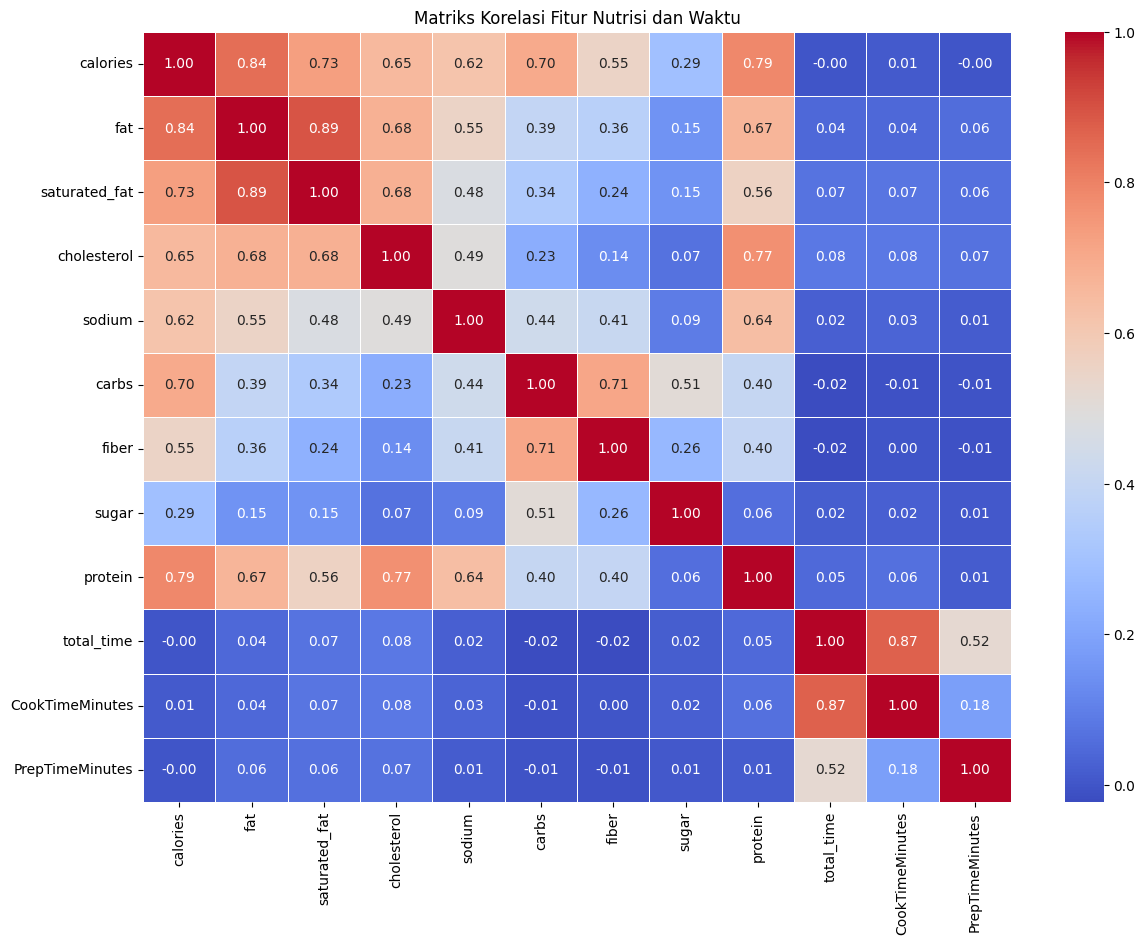

In [ ]:
# Kolom numerik yang relevan untuk korelasi
numerical_features = [
    'calories', 'fat', 'saturated_fat', 'cholesterol', 'sodium',
    'carbs', 'fiber', 'sugar', 'protein',
    'total_time', 'CookTimeMinutes', 'PrepTimeMinutes'
]

# Hitung matriks korelasi
correlation_matrix = recipes_cleaned_df[numerical_features].corr()

# Buat heatmap korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriks Korelasi Fitur Nutrisi dan Waktu')
plt.show()

### Distribusi Kalori Resep

Bagian ini menganalisis sebaran nilai kalori dari seluruh resep dalam dataset, diukur per porsi setelah proses normalisasi.

Histogram dengan kurva KDE digunakan untuk memahami bentuk distribusi — apakah mendekati normal, condong ke kanan, atau terkonsentrasi pada rentang tertentu. Hal ini penting bagi platform HealthPlan, karena kandungan kalori resep yang direkomendasikan harus sesuai dengan target kalori harian masing-masing pengguna.

Hasil analisis ini akan membantu mengidentifikasi rentang kalori yang paling umum dalam dataset dan memverifikasi bahwa data berada dalam batas yang wajar secara nutrisi setelah proses pembersihan data.

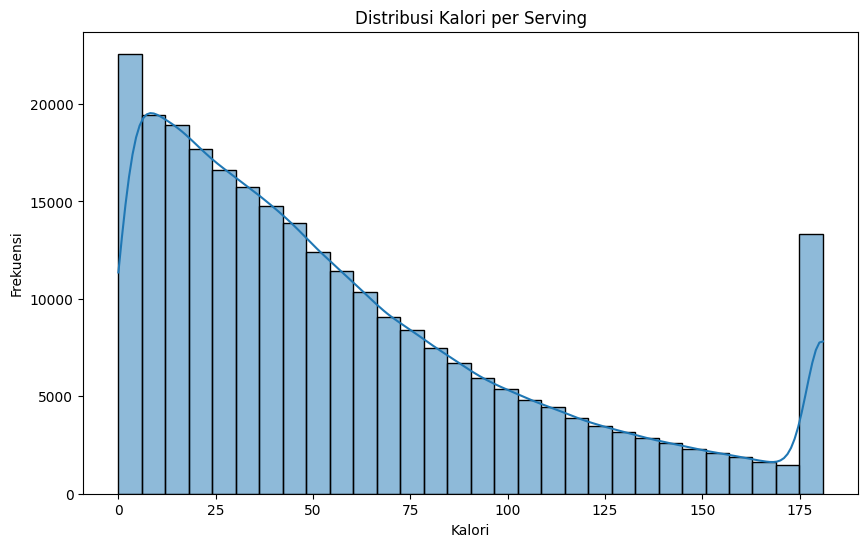

In [ ]:
# Distribusi Kalori
plt.figure(figsize=(10, 6))
sns.histplot(recipes_cleaned_df['calories'], bins=30, kde=True)
plt.title('Distribusi Kalori per Serving')
plt.xlabel('Kalori')
plt.ylabel('Frekuensi')
plt.show()

### Distribusi Total Waktu Masak

Bagian ini mengkaji sebaran total waktu memasak (dalam menit) dari seluruh resep dalam dataset.

Histogram dengan kurva KDE digunakan untuk melihat bagaimana durasi memasak tersebar — apakah sebagian besar resep dapat disiapkan dengan cepat atau membutuhkan waktu yang lebih lama. Analisis ini berkaitan langsung dengan pertanyaan bisnis yang melibatkan penyaringan resep berdasarkan batas waktu memasak di bawah 60 menit.

Hasil analisis ini akan memberikan gambaran proporsi resep yang memenuhi kriteria cepat saji dan memvalidasi bahwa pemfilteran berbasis waktu dapat diterapkan secara efektif pada data yang tersedia.

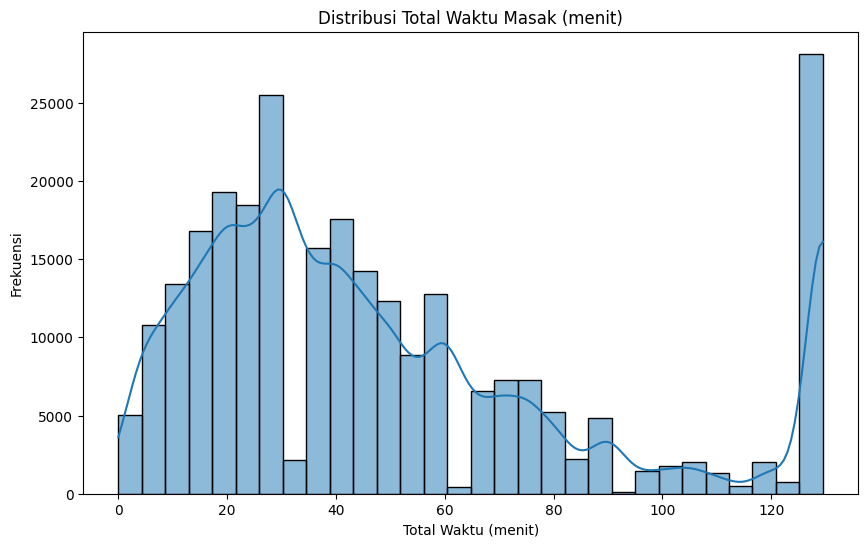

In [ ]:
# Distribusi Total Waktu Masak (dalam menit)
plt.figure(figsize=(10, 6))
sns.histplot(recipes_cleaned_df['total_time'], bins=30, kde=True)
plt.title('Distribusi Total Waktu Masak (menit)')
plt.xlabel('Total Waktu (menit)')
plt.ylabel('Frekuensi')
plt.show()

### Distribusi `RecipeCategory`

Bagian ini mengeksplorasi distribusi kategori resep dalam dataset. Mengingat banyaknya kategori unik yang tersedia, hanya 10 kategori dengan jumlah resep terbanyak yang ditampilkan.

Bar plot digunakan untuk membandingkan jumlah resep per kategori dan mengidentifikasi jenis makanan yang paling banyak terwakili dalam dataset. Pemahaman terhadap dominasi kategori ini penting bagi platform HealthPlan, karena mencerminkan ketersediaan variasi rekomendasi makanan untuk berbagai preferensi dan tujuan kesehatan pengguna.

Hasil analisis ini juga akan memberikan informasi apakah kelompok kategori tertentu memerlukan penanganan khusus agar rekomendasi yang dihasilkan tetap beragam dan seimbang.

/tmp/ipykernel_8533/2476377000.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')


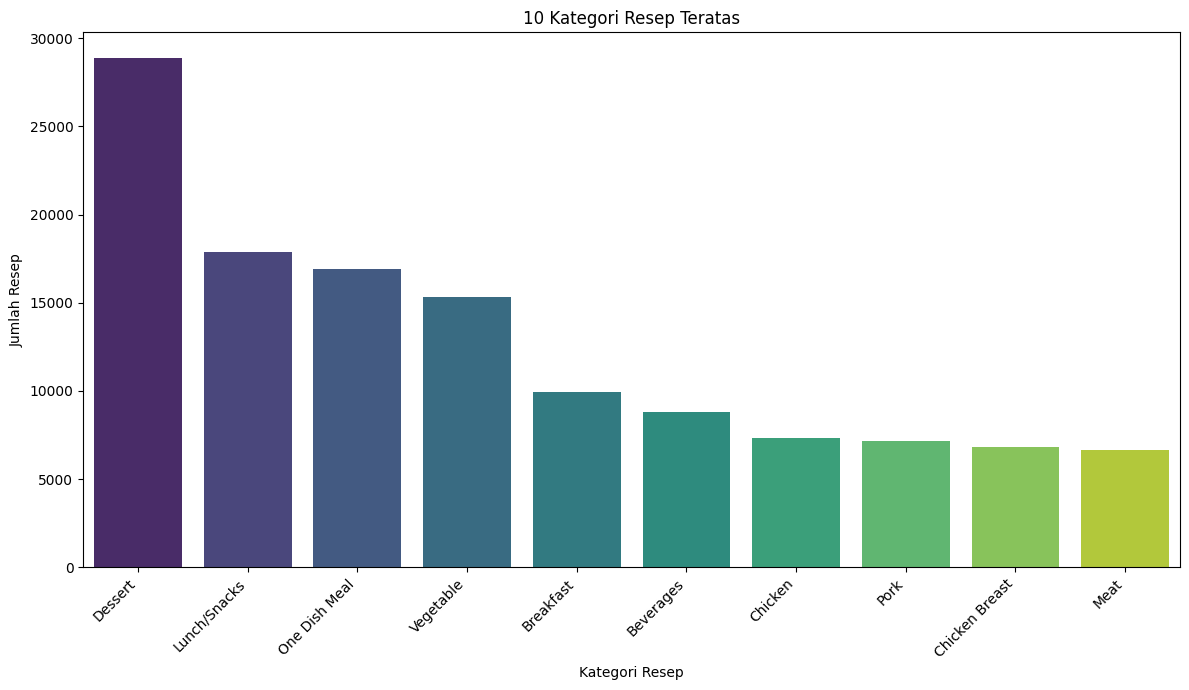

In [ ]:
# Menghitung 10 kategori resep teratas
top_categories = recipes_cleaned_df['RecipeCategory'].value_counts().head(10)

# Membuat bar plot untuk distribusi kategori resep
plt.figure(figsize=(12, 7))
sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
plt.title('10 Kategori Resep Teratas')
plt.xlabel('Kategori Resep')
plt.ylabel('Jumlah Resep')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribusi `Keywords`

Bagian ini menganalisis kata kunci yang terkait dengan setiap resep untuk memahami karakteristik tematik dari dataset. Kolom `Keywords` menyimpan data dalam format string terstruktur (`c("keyword1", "keyword2", ...)`), sehingga perlu dilakukan proses parsing terlebih dahulu sebelum dapat dianalisis.

Setelah seluruh kata kunci diekstrak dan diratakan menjadi satu daftar, 20 kata kunci yang paling sering muncul divisualisasikan menggunakan bar plot. Analisis ini bertujuan untuk mengungkap tema dan atribut dominan dalam dataset resep — seperti preferensi diet, metode memasak, atau jenis hidangan — yang nantinya dapat dimanfaatkan untuk membangun sistem penandaan dan logika rekomendasi pada platform HealthPlan.

Hasil analisis ini akan membantu mengidentifikasi kategori kata kunci mana yang paling relevan untuk dikembangkan lebih lanjut sebagai sistem filter resep.

/tmp/ipykernel_8533/2910392159.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_counts.index, y=keyword_counts.values, palette='plasma')


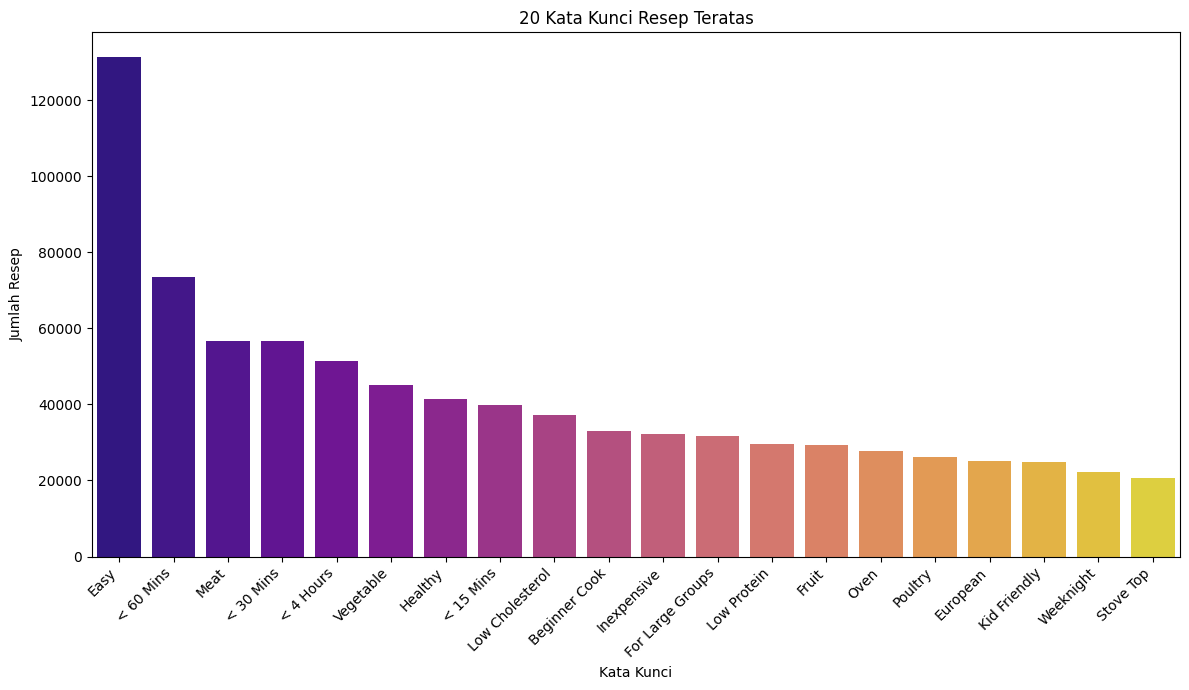

In [ ]:
# Fungsi untuk membersihkan dan mengekstrak kata kunci dari string
def extract_keywords(keywords_str):
    if isinstance(keywords_str, str) and keywords_str.startswith('c("') and keywords_str.endswith('")'):
        # Hapus 'c("' dan '")' dari string
        keywords_str = keywords_str[3:-2]
        # Pisahkan berdasarkan '", "'
        return [kw.strip() for kw in keywords_str.split('", "')] if keywords_str else []
    return []

# Terapkan fungsi ke kolom 'Keywords'
all_keywords = recipes_cleaned_df['Keywords'].apply(extract_keywords)

# Meratakan daftar menjadi satu daftar tunggal
flat_keywords = [item for sublist in all_keywords for item in sublist]

# Menghitung 20 kata kunci yang paling sering muncul
keyword_counts = pd.Series(flat_keywords).value_counts().head(20)

# Membuat bar plot untuk distribusi kata kunci
plt.figure(figsize=(12, 7))
sns.barplot(x=keyword_counts.index, y=keyword_counts.values, palette='plasma')
plt.title('20 Kata Kunci Resep Teratas')
plt.xlabel('Kata Kunci')
plt.ylabel('Jumlah Resep')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Daftar Kata Kunci Unik Keywords

Bagian ini mengekstrak dan mendaftar seluruh kata kunci unik yang terdapat di seluruh dataset resep. Berbeda dengan analisis frekuensi sebelumnya, inventaris ini berfokus pada keluasan cakupan kata kunci yang tersedia, tanpa memandang seberapa sering masing-masing kata kunci muncul.

Daftar lengkap kata kunci unik ini berfungsi sebagai referensi untuk memahami ruang lingkup atribut resep yang dapat digunakan dalam proses filtering, pencarian, dan personalisasi pada platform HealthPlan. Daftar ini juga menjadi fondasi untuk membangun taksonomi kata kunci yang terstandarisasi pada tahap rekayasa fitur selanjutnya.

In [ ]:
# Ambil daftar kata kunci unik dari 'flat_keywords'
unique_keywords = sorted(list(set(flat_keywords)))

print(f"Jumlah kata kunci unik: {len(unique_keywords)}")
print("\nDaftar kata kunci unik:")
for keyword in unique_keywords:
    print(f"- {keyword}")

Jumlah kata kunci unik: 297

Daftar kata kunci unik:
- < 15 Mins
- < 30 Mins
- < 4 Hours
- < 60 Mins
- African
- Apple
- Artichoke
- Asian
- Australian
- Austrian
- Avocado
- Baking
- Bar Cookie
- Bass
- Bath/Beauty
- Bean Soup
- Beans
- Bear
- Beef Crock Pot
- Beef Kidney
- Beef Liver
- Beef Organ Meats
- Beef Sandwiches
- Beginner Cook
- Belgian
- Berries
- Beverages
- Birthday
- Black Beans
- Brazilian
- Bread Machine
- Breads
- Breakfast
- Broil/Grill
- Brown Rice
- Brunch
- Cabbage
- Cajun
- Cambodian
- Camping
- Canadian
- Candy
- Canning
- Cantonese
- Caribbean
- Catfish
- Cauliflower
- Chard
- Cheese
- Cheesecake
- Cherries
- Chicken
- Chicken Breast
- Chicken Livers
- Chicken Stew
- Chicken Stews
- Chicken Thigh & Leg
- Chilean
- Chinese
- Chinese New Year
- Chocolate Chip Cookies
- Chowders
- Christmas
- Citrus
- Clear Soup
- Coconut
- Collard Greens
- College Food
- Colombian
- Cookie & Brownie
- Corn
- Costa Rican
- Crab
- Crawfish
- Creole
- Crock Pot Slow Cooker
- Cuban
-

### Perbandingan Waktu Memasak dan Waktu Persiapan

Bagian ini menganalisis apakah terdapat hubungan yang bermakna antara waktu persiapan (`PrepTimeMinutes`) dan waktu memasak (`CookTimeMinutes`) pada resep-resep dalam dataset.

Scatter plot digunakan untuk memvisualisasikan distribusi gabungan kedua variabel dan mengidentifikasi ada tidaknya tren atau pola pengelompokan. Selain itu, histogram terpisah untuk masing-masing variabel waktu ditampilkan untuk memahami distribusinya secara individual.

Analisis ini berkaitan langsung dengan Pertanyaan Bisnis #4, yang menanyakan apakah terdapat korelasi signifikan antara kedua dimensi waktu tersebut. Hasilnya akan menentukan apakah waktu persiapan dapat digunakan sebagai proksi untuk memperkirakan total upaya memasak, atau apakah keduanya bersifat independen — pertimbangan penting dalam merancang filter berbasis waktu bagi pengguna platform HealthPlan.

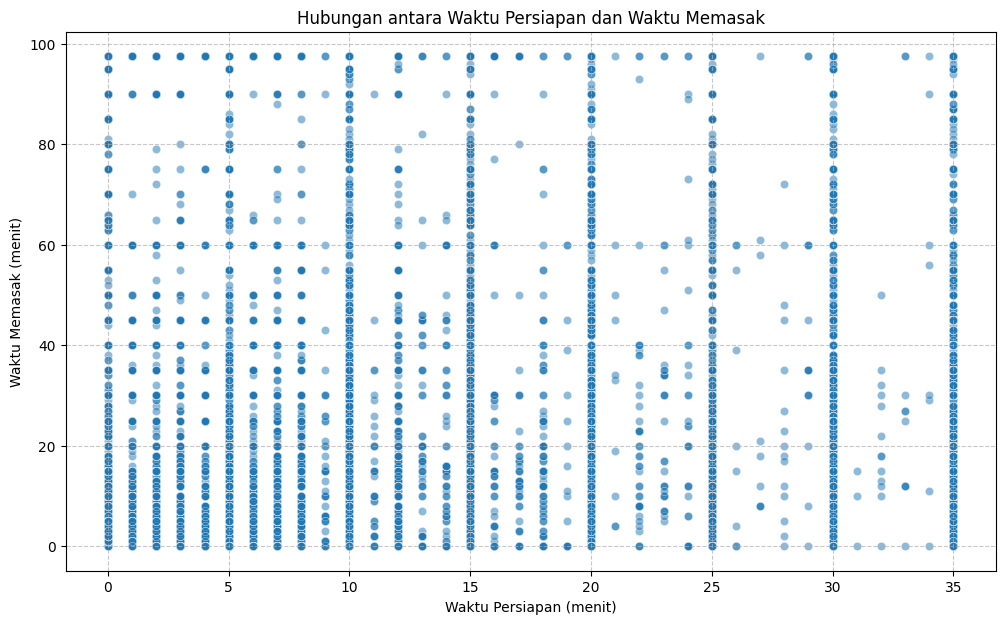

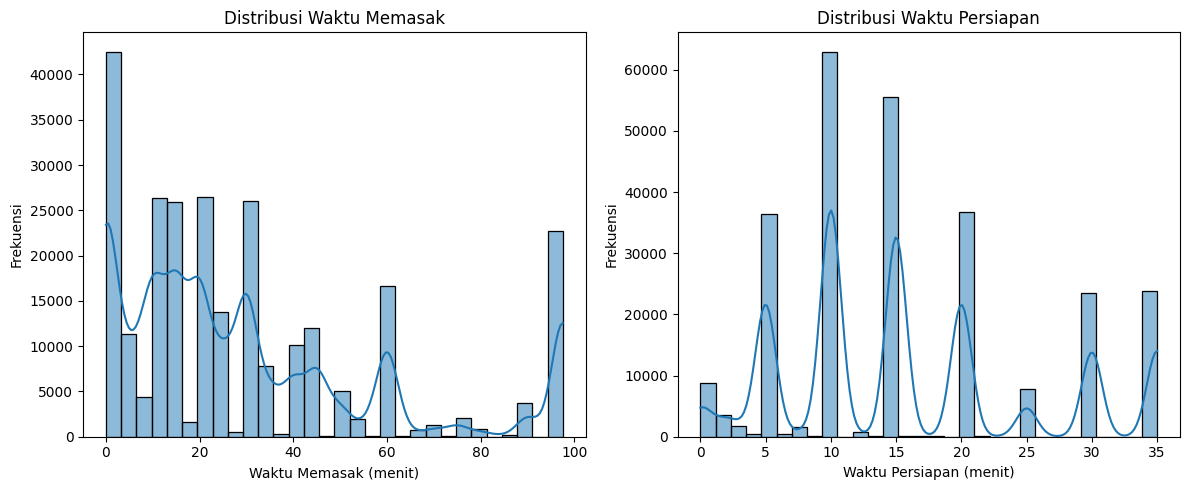

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='PrepTimeMinutes', y='CookTimeMinutes', data=recipes_cleaned_df, alpha=0.5)
plt.title('Hubungan antara Waktu Persiapan dan Waktu Memasak')
plt.xlabel('Waktu Persiapan (menit)')
plt.ylabel('Waktu Memasak (menit)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualisasi distribusi CookTimeMinutes dan PrepTimeMinutes secara terpisah
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(recipes_cleaned_df['CookTimeMinutes'], bins=30, kde=True)
plt.title('Distribusi Waktu Memasak')
plt.xlabel('Waktu Memasak (menit)')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(recipes_cleaned_df['PrepTimeMinutes'], bins=30, kde=True)
plt.title('Distribusi Waktu Persiapan')
plt.xlabel('Waktu Persiapan (menit)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### Visualisasi Box Plot untuk Nutrisi

Bagian ini memvisualisasikan sebaran dan tendensi sentral dari setiap fitur nutrisi menggunakan box plot. Fitur yang dianalisis meliputi kalori, lemak, lemak jenuh, kolesterol, sodium, karbohidrat, serat, gula, dan protein — seluruhnya diukur per porsi.

Box plot sangat berguna untuk mendeteksi keberadaan outlier, menilai rentang interkuartil (IQR), serta membandingkan simetri distribusi antar fitur. Visualisasi ini berfungsi sebagai langkah validasi pasca-pembersihan data untuk memastikan bahwa penanganan outlier yang diterapkan pada tahap data wrangling telah menghasilkan distribusi nutrisi yang wajar dan terbatas secara logis.

Hasil analisis ini akan memverifikasi kualitas data dan menyoroti anomali yang mungkin masih tersisa sebelum dataset digunakan untuk analisis pertanyaan bisnis dan pengembangan model.

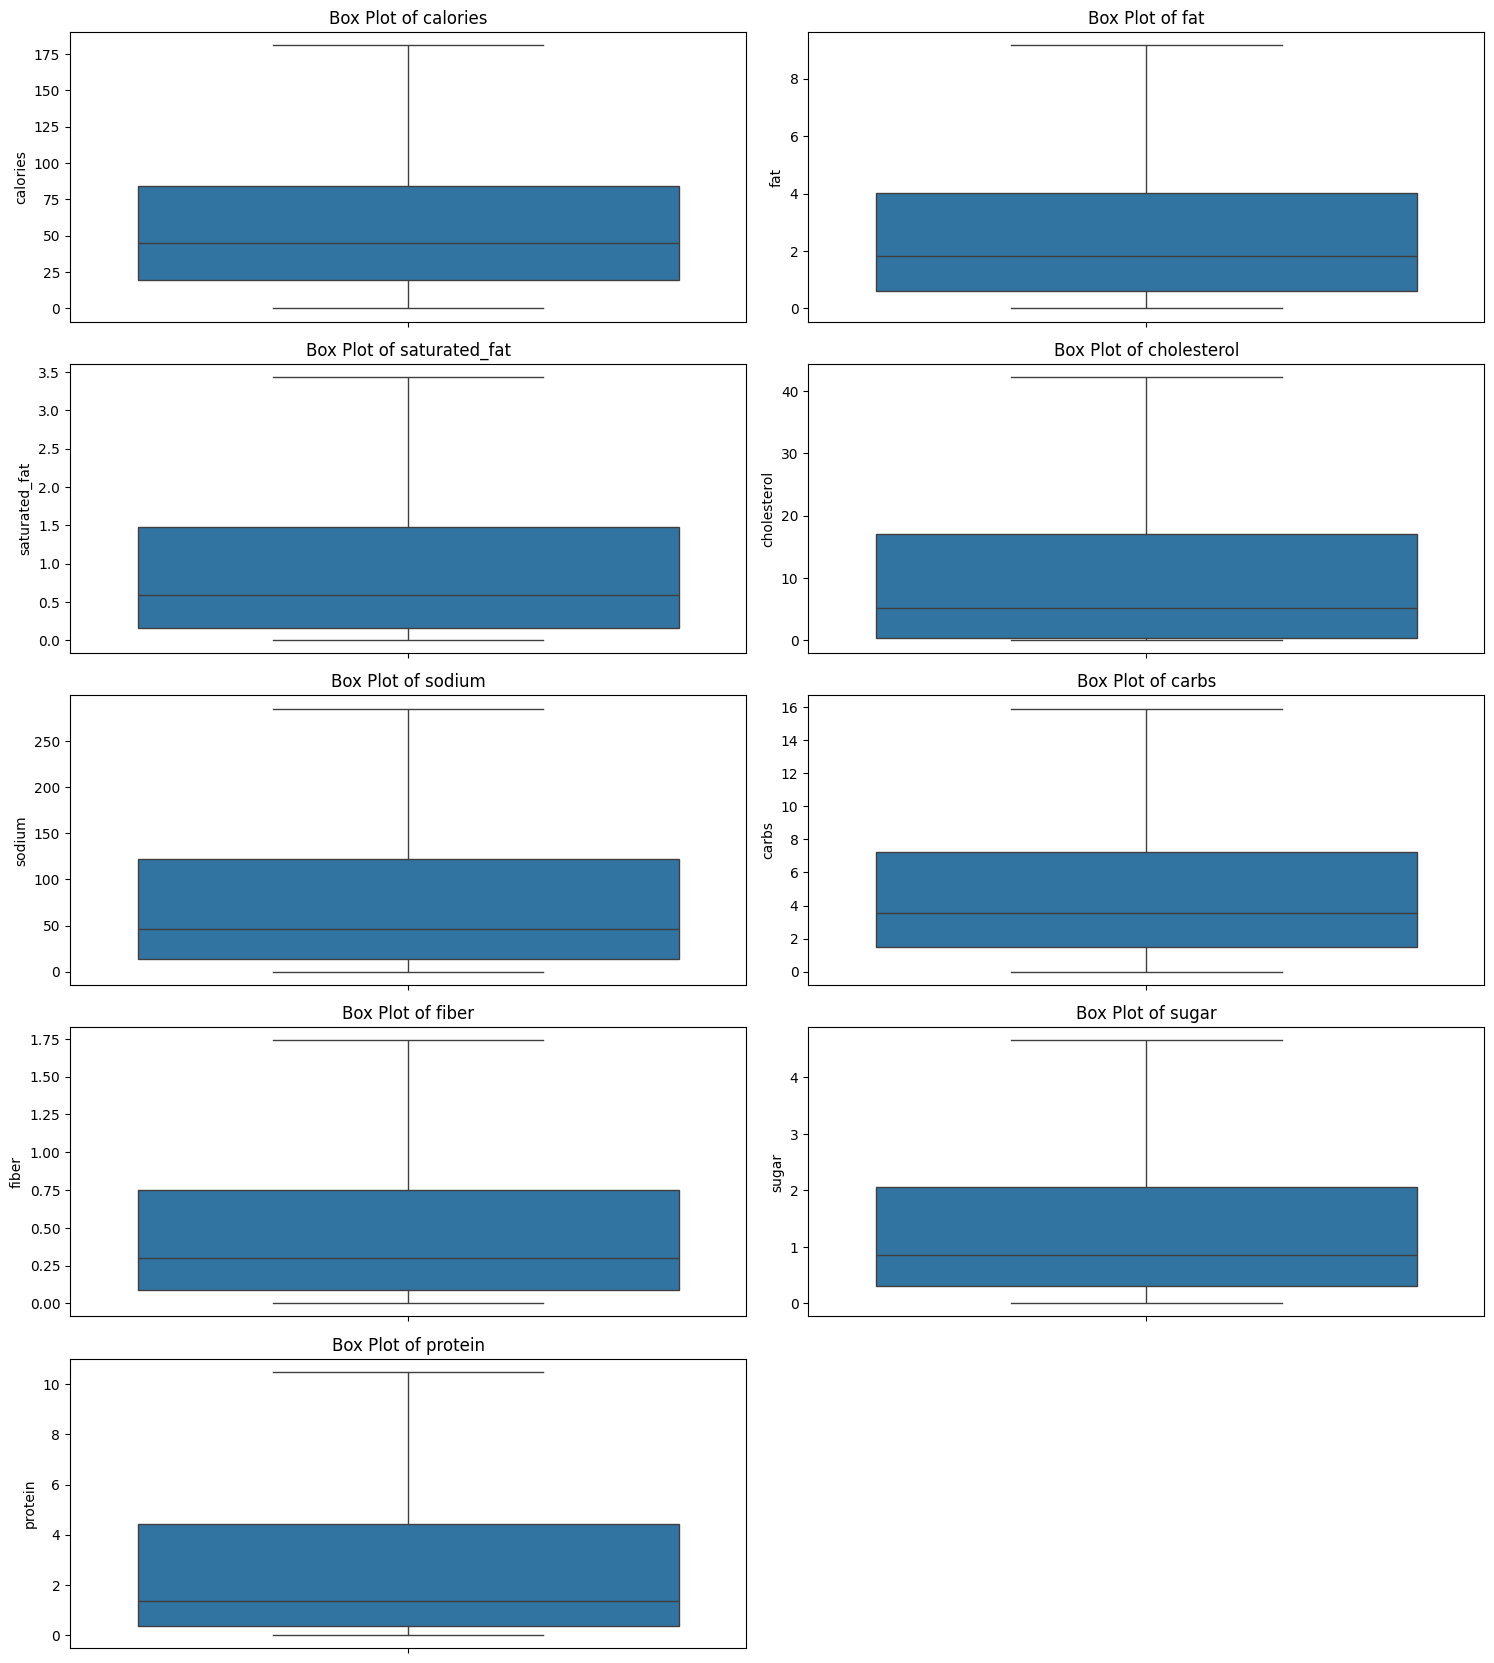

In [ ]:
# Kolom numerik yang relevan untuk box plot
nutrition_box_plot = [
    'calories', 'fat', 'saturated_fat', 'cholesterol', 'sodium', 'carbs', 'fiber', 'sugar', 'protein',
]

# Buat box plot untuk setiap fitur numerik
plt.figure(figsize=(15, 20))
for i, col in enumerate(nutrition_box_plot):
    plt.subplot(6, 2, i + 1) # Menyesuaikan grid subplot
    sns.boxplot(y=recipes_cleaned_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# BUSINESS ANSWERS & CONCLUSIONS

Dengan itu, ada beberapa pertanyaan bisnis yang kami rumuskan, yaitu:
1. Berapa banyak resep makanan yang memenuhi standar AKG (20-35% kebutuhan kalori harian, 400-700 kkal per porsi), yang bisa dimasak dalam waktu kurang dari 1 jam ?
2. Resep sehat apa yang paling sesuai direkomendasikan bagi pengguna untuk menghilangkan berat badan berdasarkan target kalori 500 kkal per meal?
3. Berapa banyak resep yang mengandung bahan yang termasuk risiko alergi bagi pengguna, yakni telur, susu, gluten, kedelai, kacang tanah dan seafood?
4. Apakah ada korelasi signifikan antara waktu persiapan dan waktu memasak?
5. Berapa banyak resep yang dapat dikategorikan kesehatannya ke dalam kategori Healthy, Moderate, Unhealthy, berdasarkan kandungan nutrisinya?
6. Apakah kombinasi tiga resep dalam sehari dapat memenuhi kebutuhan kalori harian 2000 kkal dengan distribusi nutrisi yang seimbang berdasarkan standar AKG?

## **1. Berapa banyak resep makanan yang memenuhi standar AKG (Minimal 25% kebutuhan kalori harian, 600 kkal per porsi), yang bisa dimasak dalam waktu kurang dari 1 jam ?**

In [ ]:
# Terapkan filter kalori (Minimal 600 kkal per porsi) dan total waktu (< 60 menit)
filtered_recipes = recipes_cleaned_df[
    (recipes_cleaned_df['calories'] <= 600) &
    (recipes_cleaned_df['total_time'] < 60)
]

# Hitung jumlah resep yang memenuhi kriteria
num_recipes = len(filtered_recipes)

print(f"Jumlah resep makanan yang memenuhi standar AKG (Minimal 600 kkal per porsi) dan bisa dimasak dalam waktu kurang dari 1 jam: {num_recipes} resep.")

Jumlah resep makanan yang memenuhi standar AKG (Minimal 600 kkal per porsi) dan bisa dimasak dalam waktu kurang dari 1 jam: 180457 resep.


Dari hasil di atas, kita dapat melihat bahwa ada sejumlah resep yang memenuhi kriteria kalori 600 kkal per porsi dan dapat dimasak dalam waktu kurang dari 60 menit, yaitu ada sekitar **180457 resep.**

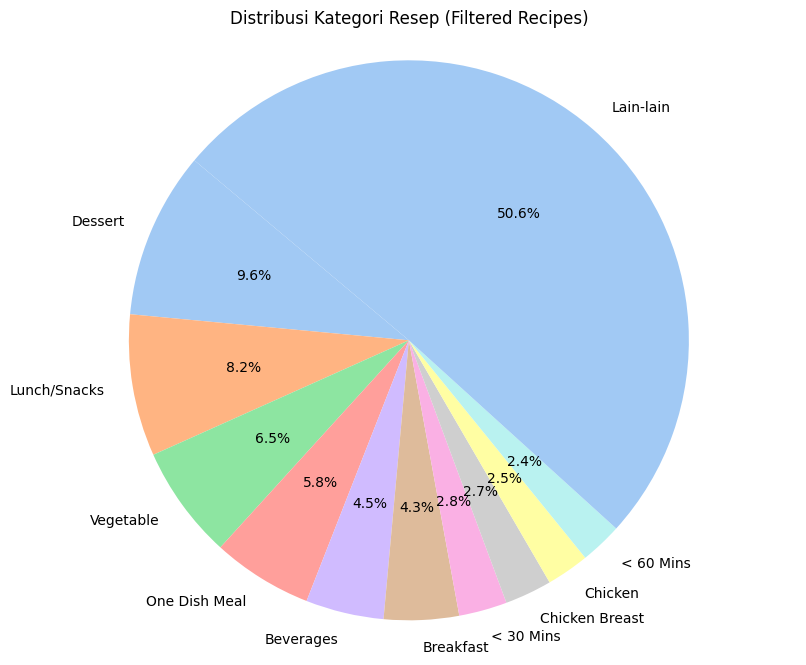

In [ ]:
# Memastikan ada data sebelum membuat visualisasi
if not filtered_recipes.empty:
    # Menghitung distribusi kategori resep
    category_counts = filtered_recipes['RecipeCategory'].value_counts()

    # Mengambil 10 kategori teratas dan menggabungkan sisanya ke 'Lain-lain'
    if len(category_counts) > 10:
        top_10_categories = category_counts.head(10)
        other_categories_sum = category_counts.iloc[10:].sum()
        if other_categories_sum > 0:
            final_categories = pd.concat([top_10_categories, pd.Series({'Lain-lain': other_categories_sum})])
        else:
            final_categories = top_10_categories
    else:
        final_categories = category_counts

    # Membuat pie chart
    plt.figure(figsize=(10, 8))
    plt.pie(final_categories, labels=final_categories.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Distribusi Kategori Resep (Filtered Recipes)')
    plt.axis('equal') # Memastikan pie chart berbentuk lingkaran sempurna
    plt.show()
else:
    print("Tidak ada resep yang memenuhi kriteria filter untuk membuat visualisasi kategori.")

In [ ]:
# Menampilkan 5 sampel resep dari data yang telah difilter
if not filtered_recipes.empty:
    print("\n10 Sampel Resep dari Data yang Terfilter:")
    display(filtered_recipes[['recipe_name', 'calories', 'total_time', 'RecipeCategory', 'Keywords']].sample(min(10, len(filtered_recipes))))
else:
    print("Tidak ada resep yang memenuhi kriteria filter untuk menampilkan sampel.")


10 Sampel Resep dari Data yang Terfilter:


,recipe_name,calories,total_time,RecipeCategory,Keywords
196248,Cast-Iron Skillet Chicken Sicilian Style,180.958333,30.0,Chicken Breast,"c(""Chicken"", ""Poultry"", ""Meat"", ""< 30 Mins"")"
66618,Basmati Rice With Turmeric and Mushrooms,101.575000,30.0,Rice,"c(""Vegetable"", ""Southwest Asia (middle East)"",..."
235845,Lemon Glaze Cake,33.283333,50.0,Dessert,"""< 60 Mins"""
10591,Downeast Fish Chowder,47.600000,50.0,Chowders,"c(""< 60 Mins"", ""Easy"")"
9502,Crunchy Pea Salad,76.566667,20.0,Cauliflower,"c(""Vegetable"", ""Potluck"", ""< 30 Mins"", ""Refrig..."
101235,Broiled Pink Grapefruit,38.000000,25.0,Breakfast,"c(""Citrus"", ""Fruit"", ""Low Protein"", ""Low Chole..."
202930,Simple Cinnamon Scones,10.616667,25.0,Scones,"c(""Quick Breads"", ""Breads"", ""Healthy"", ""< 30 M..."
157474,Nickel Fever Cocktail,96.800000,2.0,Beverages,"c(""Australian"", ""< 15 Mins"", ""Easy"")"
176778,Crab Louis With Avocado,177.000000,10.0,Crab,"c(""< 15 Mins"", ""Easy"")"
28473,"BROILED, ""SMOKIE"" CATFISH",56.075000,16.0,Catfish,"c(""Southwestern U.S."", ""Canadian"", ""Brunch"", ""..."


### **Jawaban**

Berdasarkan kriteria filter yang telah diperbarui (kalori minimal 600 kkal per porsi dan total waktu memasak kurang dari 60 menit), ditemukan **180.457 resep** yang memenuhi standar tersebut. Jumlah ini menunjukkan bahwa ada banyak pilihan resep yang relatif cepat untuk disiapkan dan memiliki kandungan kalori yang memadai.

Visualisasi pie chart dari kategori resep teratas dari data yang terfilter memberikan gambaran tentang jenis resep yang paling sering muncul dalam kriteria ini. Ini dapat memberikan gambaran awal tentang ketersediaan resep cepat saji dengan kalori yang sesuai. Dengan adanya 10 kategori teratas dan pengelompokan 'Lain-lain', kita bisa melihat dominasi kategori tertentu atau keberagaman resep secara umum.

### **Kesimpulan**

Sejumlah besar resep memenuhi kriteria kalori minimal 600 kkal dan total waktu memasak kurang dari 60 menit, menunjukkan potensi besar untuk menyajikan rekomendasi cepat dan bergizi. Analisis kategori lebih lanjut akan membantu dalam memahami tren dan preferensi pengguna dalam konteks resep cepat saji dan berkalori cukup.


## **2. Resep sehat apa yang paling sesuai direkomendasikan bagi pengguna untuk menghilangkan berat badan berdasarkan target kalori 500 kkal per meal?**

In [ ]:
# Tentukan rentang kalori untuk 'sekitar 500 kkal'
min_calories = 100
max_calories = 500

# Filter resep yang memenuhi kriteria kalori
weight_loss_recipes = recipes_cleaned_df[
    (recipes_cleaned_df['calories'] >= min_calories) &
    (recipes_cleaned_df['calories'] <= max_calories)
]

# Hitung jumlah resep yang memenuhi kriteria
num_weight_loss_recipes = len(weight_loss_recipes)

print(f"Jumlah resep sehat dengan kalori antara {min_calories}-{max_calories} kkal per porsi: {num_weight_loss_recipes} resep.")

# Tampilkan beberapa sampel resep
if not weight_loss_recipes.empty:
    print("\n5 Sampel Resep untuk Rekomendasi Penurunan Berat Badan:")
    display(weight_loss_recipes[['recipe_name', 'calories', 'total_time', 'RecipeCategory', 'Keywords']].sample(min(5, len(weight_loss_recipes)), random_state=42))
else:
    print("Tidak ada resep yang ditemukan dalam rentang kalori yang ditentukan.")

Jumlah resep sehat dengan kalori antara 100-500 kkal per porsi: 50235 resep.

5 Sampel Resep untuk Rekomendasi Penurunan Berat Badan:


,recipe_name,calories,total_time,RecipeCategory,Keywords
120634,Dennis's Stew,100.633333,129.5,Stew,"""Easy"""
81823,Southwestern Chorizo Quesadillas,180.958333,25.0,Lunch/Snacks,"c(""Pork"", ""Cheese"", ""Meat"", ""Tex Mex"", ""Southw..."
82403,1/2 Cup Soup,104.600000,30.0,Vegetable,"c(""Low Cholesterol"", ""Healthy"", ""< 30 Mins"", ""..."
27492,Pasta with Chicken and Broccoli,180.958333,20.0,One Dish Meal,"c(""Chicken"", ""Penne"", ""Poultry"", ""Vegetable"", ..."
237920,Pumpkin Pie-Croissant Pudding,150.383333,55.0,Dessert,"c(""Vegetable"", ""< 60 Mins"", ""Easy"")"


/tmp/ipykernel_8533/1863060530.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories_weight_loss.index, y=top_categories_weight_loss.values, palette='viridis')


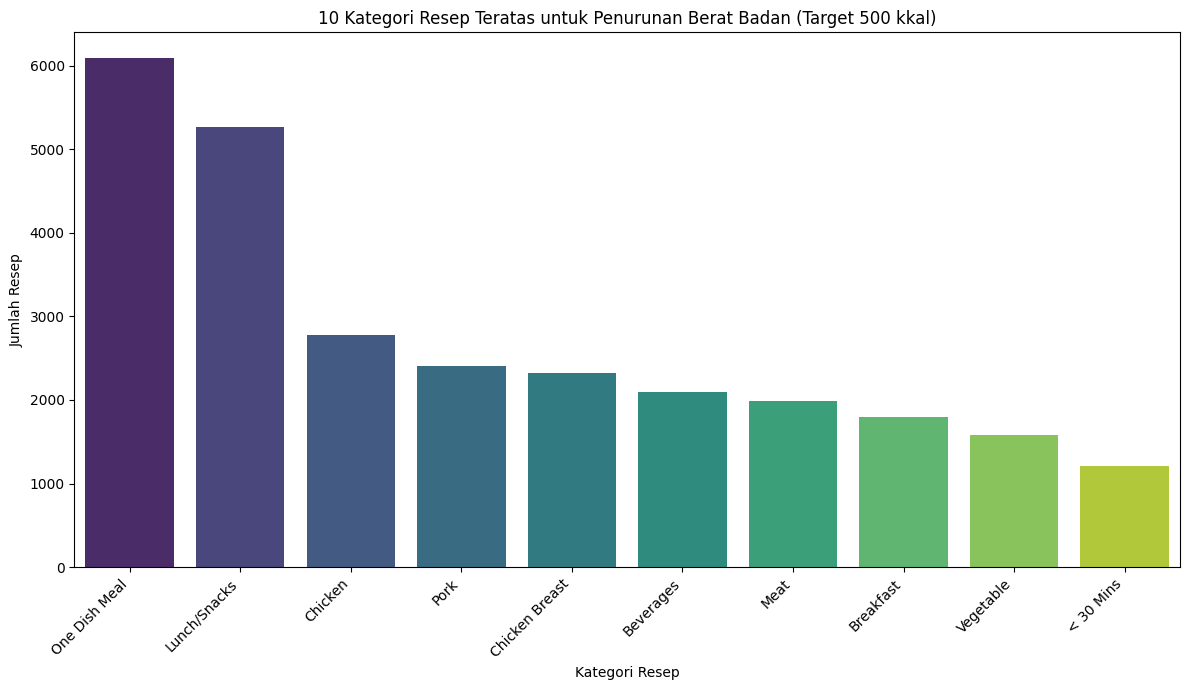

In [ ]:
if not weight_loss_recipes.empty:
    # Menghitung 10 kategori resep teratas dari resep yang terfilter
    top_categories_weight_loss = weight_loss_recipes['RecipeCategory'].value_counts().head(10)

    # Membuat bar plot untuk distribusi kategori resep
    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_categories_weight_loss.index, y=top_categories_weight_loss.values, palette='viridis')
    plt.title('10 Kategori Resep Teratas untuk Penurunan Berat Badan (Target 500 kkal)')
    plt.xlabel('Kategori Resep')
    plt.ylabel('Jumlah Resep')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data resep yang memenuhi kriteria untuk membuat visualisasi kategori.")

### **Jawaban**

Berdasarkan filter resep dengan kalori antara 100-500 kkal per porsi, ditemukan **50.235 resep** yang dapat direkomendasikan untuk pengguna yang ingin menurunkan berat badan. Jumlah resep ini cukup signifikan untuk memberikan variasi pilihan kepada pengguna.

Visualisasi bar chart menunjukkan kategori resep yang paling umum dalam kelompok ini. Kategori seperti 'One Dish Meal', 'Lunch/Snacks', dan 'Chicken' mendominasi, menunjukkan bahwa resep untuk makan siang/makan malam yang mudah dan berbahan dasar ayam atau hidangan lengkap sangat populer dalam rentang kalori ini.

### **Kesimpulan**
Terdapat banyak resep yang memenuhi kriteria kalori 100-500 kkal per porsi, menjadikannya pilihan yang sangat baik untuk rekomendasi penurunan berat badan. Dengan menganalisis kategori resep ini, platform HealthPlan dapat secara efektif merekomendasikan hidangan yang bervariasi dan sesuai dengan tujuan diet pengguna. Untuk rekomendasi yang lebih personal, integrasi dengan preferensi pengguna (misalnya, bahan yang disukai atau alergi) akan sangat bermanfaat.

## **3. Berapa banyak resep yang mengandung bahan yang termasuk risiko alergi bagi pengguna, yakni telur, susu, gluten, kedelai, kacang tanah dan seafood?**

Untuk menjawab pertanyaan ini, kita akan mengidentifikasi resep-resep yang mengandung bahan-bahan umum pemicu alergi seperti telur, susu, gluten, kedelai, kacang tanah, dan seafood. Kita akan mengekstrak bahan-bahan dari kolom `RecipeIngredientParts` dan membuat penanda untuk setiap jenis alergen.

Jumlah resep yang mengandung setidaknya satu risiko alergi: 185636 resep.


/tmp/ipykernel_8533/4106518851.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=allergen_counts_series.index, y=allergen_counts_series.values, palette='viridis')


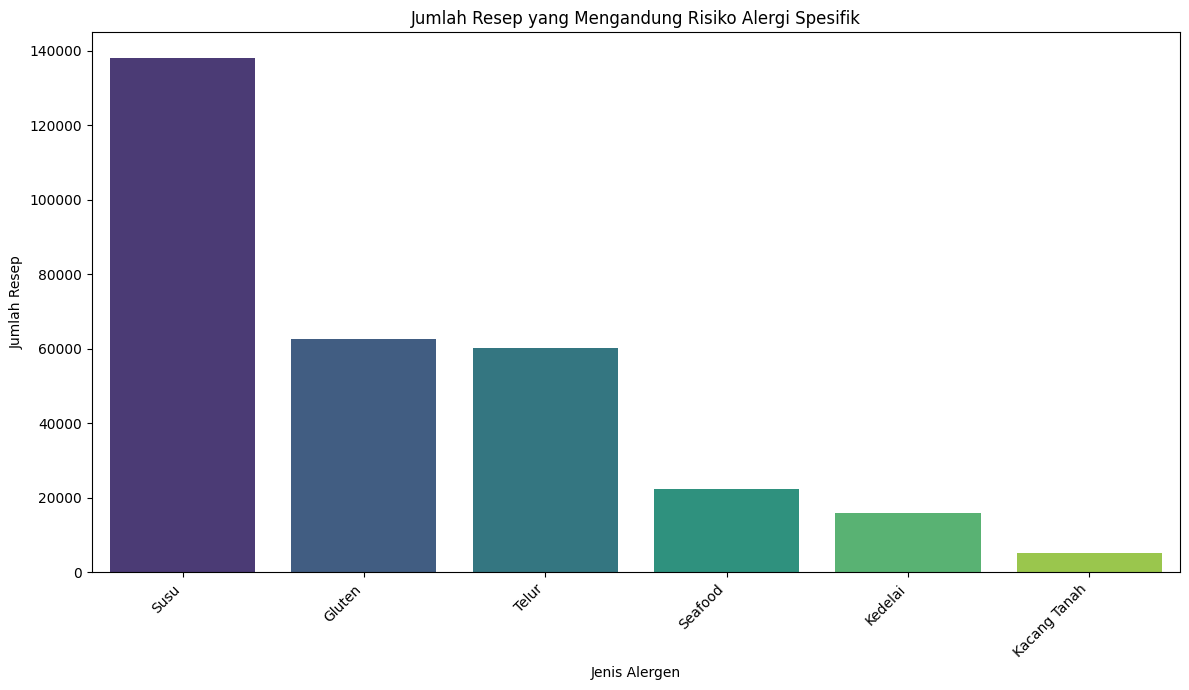


5 Sampel Resep yang Mengandung Setidaknya Satu Alergen:


,recipe_name,RecipeIngredientParts,RecipeCategory,Keywords
35940,10 Minute Meal,"c(""water"", ""onion"", ""carrot"", ""celery"", ""mushr...",Very Low Carbs,"c(""Low Protein"", ""Low Cholesterol"", ""< 15 Mins..."
201401,Baked Potatoes for Breakfast,"c(""baking potatoes"", ""butter"", ""parmesan chees...",Breakfast,"c(""Potato"", ""Vegetable"", ""Brunch"", ""< 60 Mins""..."
174692,Favorite Farm Muffins,"c(""raisins"", ""baking soda"", ""boiling water"", ""...",Quick Breads,"c(""Breads"", ""< 30 Mins"", ""For Large Groups"", ""..."
220522,Prawns With Garlic in a Spiced Dhal Curry,"c(""onion"", ""garlic cloves"", ""ginger"", ""tomatoe...",Asian,"""< 60 Mins"""
178805,Shrimp Souvlaki (Ww),"c(""cucumber"", ""kosher salt"", ""red wine vinegar...",Greek,"c(""European"", ""Broil/Grill"", ""< 15 Mins"", ""Oven"")"


In [ ]:
# Fungsi untuk mengekstrak bahan-bahan dari string 'RecipeIngredientParts'
def extract_ingredients(ingredients_str):
    if isinstance(ingredients_str, str) and ingredients_str.startswith('c("') and ingredients_str.endswith('")'):
        # Hapus 'c("' dan '")' dari string
        ingredients_str = ingredients_str[3:-2]
        # Pisahkan berdasarkan '", "' dan konversi ke huruf kecil untuk pencocokan case-insensitive
        return [ing.strip().lower() for ing in ingredients_str.split('", "')] if ingredients_str else []
    return []

# Definisikan daftar alergen beserta kata kunci terkait (dalam Bahasa Indonesia dan Inggris)
allergens = {
    'Telur': ['telur', 'egg'],
    'Susu': ['susu', 'milk', 'dairy', 'keju', 'cheese', 'mentega', 'butter'],
    'Gluten': ['gluten', 'gandum', 'wheat', 'tepung terigu', 'flour', 'roti', 'bread'],
    'Kedelai': ['kedelai', 'soy', 'tofu', 'tempeh'],
    'Kacang Tanah': ['kacang tanah', 'peanut', 'kacang'],
    'Seafood': ['seafood', 'ikan', 'fish', 'udang', 'shrimp', 'kepiting', 'crab', 'kerang', 'shellfish', 'cumi', 'squid']
}

# Buat kolom boolean untuk setiap kategori alergen
# Kolom ini akan bernilai True jika resep mengandung setidaknya satu kata kunci dari kategori alergen tersebut
for category, keywords in allergens.items():
    recipes_cleaned_df[f'has_{category.lower().replace(" ", "_")}'] = recipes_cleaned_df['RecipeIngredientParts'].apply(
        lambda x: any(any(keyword in ing for ing in extract_ingredients(x)) for keyword in keywords)
    )

# Hitung total resep yang mengandung setidaknya satu alergen
has_any_allergen_cols = [f'has_{category.lower().replace(" ", "_")}' for category in allergens.keys()]
recipes_cleaned_df['has_any_allergen'] = recipes_cleaned_df[has_any_allergen_cols].any(axis=1)
num_recipes_with_any_allergen = recipes_cleaned_df['has_any_allergen'].sum()

print(f"Jumlah resep yang mengandung setidaknya satu risiko alergi: {num_recipes_with_any_allergen} resep.")

# Siapkan data untuk visualisasi: hitung jumlah resep untuk setiap jenis alergen
allergen_counts = {}
for category in allergens.keys():
    allergen_counts[category] = recipes_cleaned_df[f'has_{category.lower().replace(" ", "_")}'].sum()

allergen_counts_series = pd.Series(allergen_counts).sort_values(ascending=False)

# Visualisasikan distribusi resep yang mengandung alergen spesifik
plt.figure(figsize=(12, 7))
sns.barplot(x=allergen_counts_series.index, y=allergen_counts_series.values, palette='viridis')
plt.title('Jumlah Resep yang Mengandung Risiko Alergi Spesifik')
plt.xlabel('Jenis Alergen')
plt.ylabel('Jumlah Resep')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Tampilkan 5 sampel resep yang mengandung setidaknya satu alergen
if not recipes_cleaned_df[recipes_cleaned_df['has_any_allergen']].empty:
    print("\n5 Sampel Resep yang Mengandung Setidaknya Satu Alergen:")
    display(recipes_cleaned_df[recipes_cleaned_df['has_any_allergen']][
        ['recipe_name', 'RecipeIngredientParts', 'RecipeCategory', 'Keywords']
    ].sample(min(5, len(recipes_cleaned_df[recipes_cleaned_df['has_any_allergen']])), random_state=42))
else:
    print("Tidak ada resep yang ditemukan mengandung alergen.")

### **Jawaban**

Berdasarkan analisis, ditemukan sejumlah besar resep yang mengandung setidaknya satu jenis alergen. Visualisasi menunjukkan distribusi resep untuk setiap kategori alergen (telur, susu, gluten, kedelai, kacang tanah, seafood).

**Insight:**
*   Alergen seperti susu, gluten, dan telur terlihat paling sering muncul dalam dataset resep ini, menunjukkan bahwa bahan-bahan ini umum digunakan.
*   Platform HealthPlan dapat menggunakan informasi ini untuk menyaring resep atau memberikan peringatan kepada pengguna yang memiliki alergi spesifik, meningkatkan pengalaman personalisasi dan keamanan.

### **Kesimpulan**
Identifikasi alergen dalam resep merupakan langkah penting untuk memastikan keamanan dan relevansi rekomendasi bagi pengguna dengan kondisi alergi. Dengan data ini, HealthPlan dapat mengembangkan fitur penyaringan alergen yang efektif, memungkinkan pengguna untuk menemukan resep yang aman dan sesuai dengan kebutuhan diet mereka.

## **4. Apakah ada korelasi signifikan antara waktu persiapan dan waktu memasak?**

Untuk menjawab pertanyaan ini, kita akan melihat korelasi antara kolom `PrepTimeMinutes` (waktu persiapan) dan `CookTimeMinutes` (waktu memasak). Visualisasi seperti scatter plot dan matriks korelasi dapat membantu kita memahami hubungan ini.

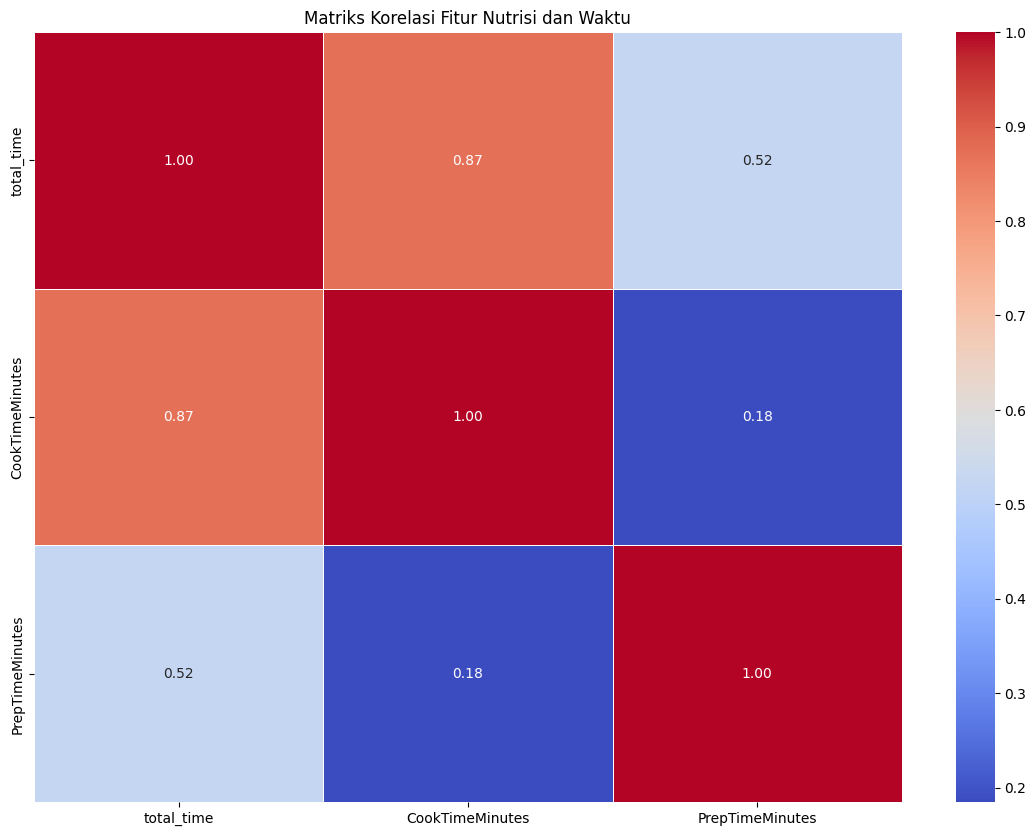

In [ ]:
# Kolom numerik yang relevan untuk korelasi
cooktime_numerical_features = ['total_time', 'CookTimeMinutes', 'PrepTimeMinutes']

# Hitung matriks korelasi
correlation_matrix = recipes_cleaned_df[cooktime_numerical_features].corr()

# Buat heatmap korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriks Korelasi Fitur Nutrisi dan Waktu')
plt.show()

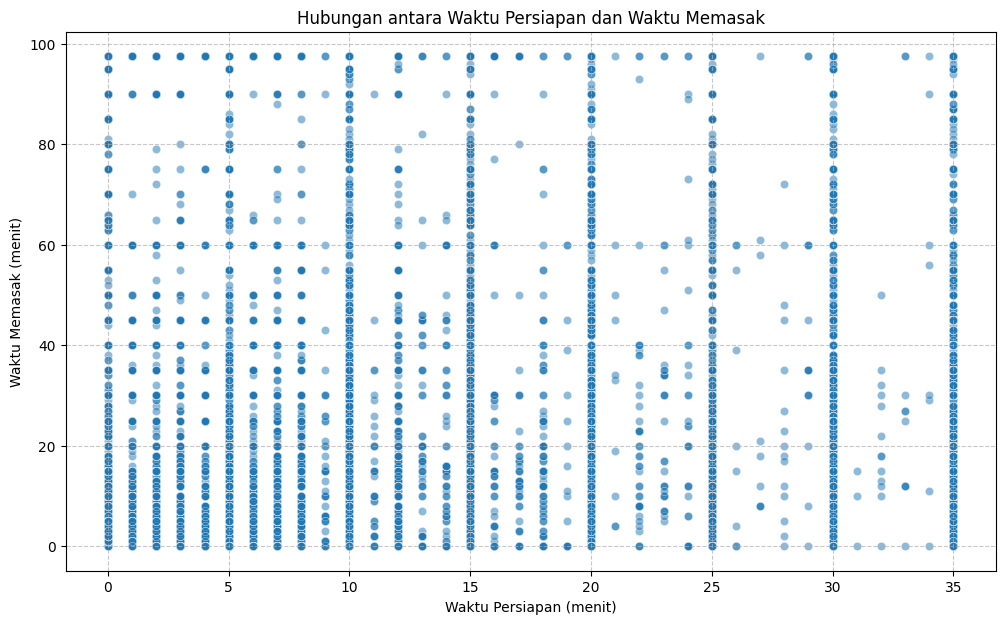

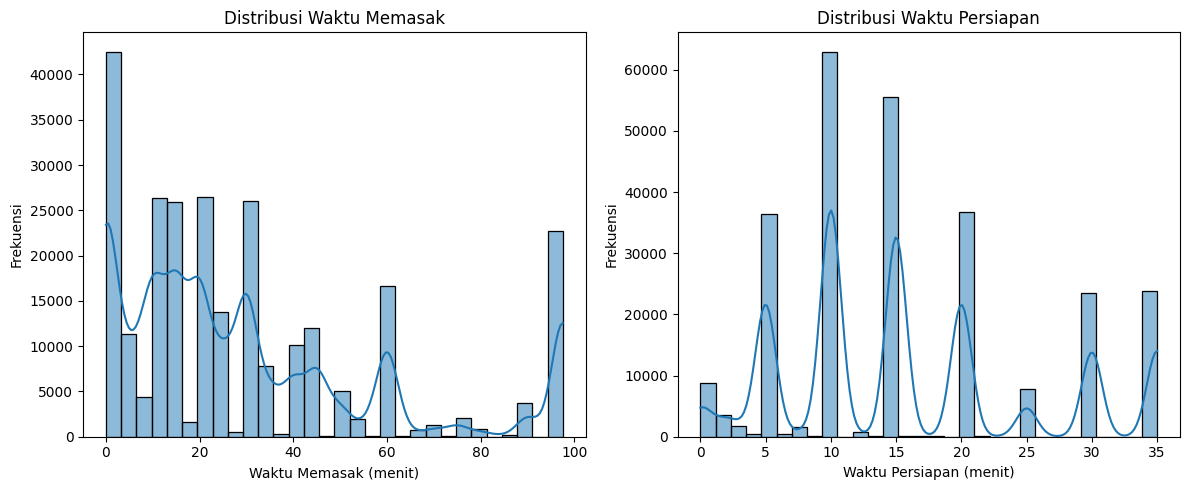

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='PrepTimeMinutes', y='CookTimeMinutes', data=recipes_cleaned_df, alpha=0.5)
plt.title('Hubungan antara Waktu Persiapan dan Waktu Memasak')
plt.xlabel('Waktu Persiapan (menit)')
plt.ylabel('Waktu Memasak (menit)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualisasi distribusi CookTimeMinutes dan PrepTimeMinutes secara terpisah
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(recipes_cleaned_df['CookTimeMinutes'], bins=30, kde=True)
plt.title('Distribusi Waktu Memasak')
plt.xlabel('Waktu Memasak (menit)')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(recipes_cleaned_df['PrepTimeMinutes'], bins=30, kde=True)
plt.title('Distribusi Waktu Persiapan')
plt.xlabel('Waktu Persiapan (menit)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### Jawaban

Berdasarkan matriks korelasi yang telah kita buat sebelumnya, **korelasi antara `PrepTimeMinutes` dan `CookTimeMinutes` adalah positif, namun tidak terlalu signifikan, yaitu sekitar 0.18**. Ini menunjukkan bahwa ada sedikit kecenderungan resep dengan waktu persiapan yang lebih lama juga memiliki waktu memasak yang lebih lama, tetapi hubungannya lemah.

Dari scatter plot hubungan antara Waktu Persiapan dan Waktu Memasak, kita dapat melihat bahwa titik-titik data tersebar cukup luas. Meskipun ada konsentrasi data pada durasi waktu yang lebih pendek untuk kedua variabel, tidak ada pola linier yang kuat yang menunjukkan korelasi tinggi. Artinya, waktu yang dihabiskan untuk persiapan tidak selalu berbanding lurus dengan waktu yang dibutuhkan untuk memasak.

Histori distribusi `CookTimeMinutes` dan `PrepTimeMinutes` menunjukkan bahwa sebagian besar resep memiliki waktu persiapan dan waktu memasak yang relatif singkat, dengan puncaknya berada di bawah 60 menit untuk waktu memasak dan di bawah 30 menit untuk waktu persiapan.

### **Kesimpulan**

Tidak ada korelasi yang sangat signifikan antara waktu persiapan (`PrepTimeMinutes`) dan waktu memasak (`CookTimeMinutes`). Korelasi positif yang lemah menunjukkan bahwa kedua metrik waktu ini cenderung bervariasi secara independen untuk sebagian besar resep. Hal ini mengindikasikan bahwa sebuah resep dengan waktu persiapan yang panjang belum tentu memiliki waktu memasak yang panjang pula, begitu pula sebaliknya.

**Insight:**
*   Untuk calon pengguna HealthPlan, informasi ini berarti bahwa mereka tidak perlu khawatir bahwa resep dengan waktu persiapan singkat pasti akan memiliki waktu memasak yang panjang, atau sebaliknya.
*   Platform dapat merekomendasikan resep yang 'cepat saji' secara keseluruhan (total waktu rendah) tanpa harus mengorbankan waktu persiapan atau memasak secara spesifik, karena keduanya tidak saling terikat secara kuat.

## **5. Berapa banyak resep yang dapat dikategorikan kesehatannya ke dalam kategori Healthy, Moderate, Unhealthy, berdasarkan kandungan nutrisinya?**

Untuk menjawab pertanyaan ini, kita akan membuat kategori kesehatan (Healthy, Moderate, Unhealthy) untuk setiap resep berdasarkan ambang batas nutrisi tertentu. Setelah itu, kita akan menghitung dan memvisualisasikan jumlah resep di setiap kategori.

Jumlah resep per kategori kesehatan:
HealthCategory
Healthy     170244
Moderate     94606
Name: count, dtype: int64


/tmp/ipykernel_8533/2176109775.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=health_category_counts.index, y=health_category_counts.values, palette='coolwarm')


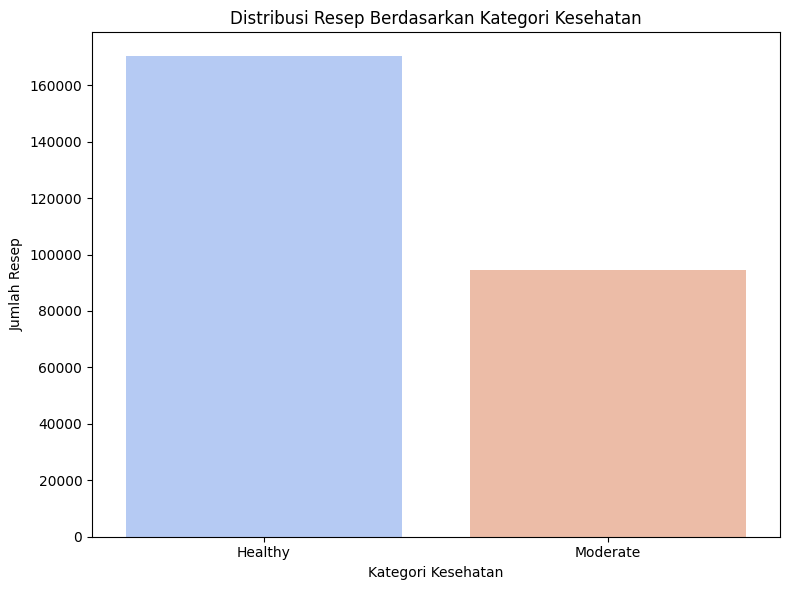


Sampel Resep Kategori 'Healthy':


,recipe_name,calories,fat,protein,HealthCategory
96726,Dietetic Cornmeal Cookies,1.736111,0.111111,0.022222,Healthy
182778,Cinnamon Sugar Cookies – Only 1 Weight Watcher...,2.486667,0.110000,0.030000,Healthy
49466,Christmas Potpourri,14.780000,0.040000,0.300000,Healthy
208172,Tomato Fennel Salad,14.283333,0.800000,0.283333,Healthy
165429,Cloved Onions,54.325000,2.200000,0.425000,Healthy



Sampel Resep Kategori 'Moderate':


,recipe_name,calories,fat,protein,HealthCategory
90541,Traditional Senoran Enchiladas Done Casserole...,48.875000,3.425000,2.062500,Moderate
221963,Wild Rice in Vermouth,78.075000,3.025000,2.025000,Moderate
256588,Capper's Farmer Cider-Braised Spicy Pork Stew,84.933333,5.933333,4.683333,Moderate
76786,Avocado Turkey Wraps,85.050000,4.850000,4.700000,Moderate
42595,Roasted Caramelized Balsamic Onions,37.675000,2.900000,0.275000,Moderate



Sampel Resep Kategori 'Unhealthy':


,recipe_name,calories,fat,protein,HealthCategory


In [ ]:
# Definisikan ambang batas nutrisi (per serving) untuk kategorisasi
# Ambang batas ini disesuaikan untuk dataset yang sudah dinormalisasi per serving

# Kriteria 'Healthy'
HEALTHY_CALORIES_MAX = 200
HEALTHY_FAT_MAX = 5
HEALTHY_SAT_FAT_MAX = 1.5
HEALTHY_CHOLESTEROL_MAX = 20
HEALTHY_SODIUM_MAX = 140
HEALTHY_SUGAR_MAX = 5
HEALTHY_PROTEIN_MIN = 5
HEALTHY_FIBER_MIN = 2

# Kriteria 'Unhealthy' (jika melampaui salah satu ambang batas ini)
UNHEALTHY_CALORIES_MIN = 400
UNHEALTHY_FAT_MIN = 15
UNHEALTHY_SAT_FAT_MIN = 5
UNHEALTHY_CHOLESTEROL_MIN = 60
UNHEALTHY_SODIUM_MIN = 400
UNHEALTHY_SUGAR_MIN = 15

def categorize_health(row):
    is_healthy_count = 0
    is_unhealthy_count = 0

    # Check Healthy criteria
    if row['calories'] <= HEALTHY_CALORIES_MAX: is_healthy_count += 1
    if row['fat'] <= HEALTHY_FAT_MAX: is_healthy_count += 1
    if row['saturated_fat'] <= HEALTHY_SAT_FAT_MAX: is_healthy_count += 1
    if row['cholesterol'] <= HEALTHY_CHOLESTEROL_MAX: is_healthy_count += 1
    if row['sodium'] <= HEALTHY_SODIUM_MAX: is_healthy_count += 1
    if row['sugar'] <= HEALTHY_SUGAR_MAX: is_healthy_count += 1
    if row['protein'] >= HEALTHY_PROTEIN_MIN: is_healthy_count += 1
    if row['fiber'] >= HEALTHY_FIBER_MIN: is_healthy_count += 1

    # Check Unhealthy criteria
    if row['calories'] > UNHEALTHY_CALORIES_MIN: is_unhealthy_count += 1
    if row['fat'] > UNHEALTHY_FAT_MIN: is_unhealthy_count += 1
    if row['saturated_fat'] > UNHEALTHY_SAT_FAT_MIN: is_unhealthy_count += 1
    if row['cholesterol'] > UNHEALTHY_CHOLESTEROL_MIN: is_unhealthy_count += 1
    if row['sodium'] > UNHEALTHY_SODIUM_MIN: is_unhealthy_count += 1
    if row['sugar'] > UNHEALTHY_SUGAR_MIN: is_unhealthy_count += 1

    if is_healthy_count >= 6: # Arbitrary threshold, can be adjusted
        return 'Healthy'
    elif is_unhealthy_count >= 3: # Arbitrary threshold, can be adjusted
        return 'Unhealthy'
    else:
        return 'Moderate'

# Terapkan fungsi kategorisasi
recipes_cleaned_df['HealthCategory'] = recipes_cleaned_df.apply(categorize_health, axis=1)

# Hitung jumlah resep di setiap kategori kesehatan
health_category_counts = recipes_cleaned_df['HealthCategory'].value_counts()

print("Jumlah resep per kategori kesehatan:")
print(health_category_counts)

# Visualisasikan distribusi kategori kesehatan
plt.figure(figsize=(8, 6))
sns.barplot(x=health_category_counts.index, y=health_category_counts.values, palette='coolwarm')
plt.title('Distribusi Resep Berdasarkan Kategori Kesehatan')
plt.xlabel('Kategori Kesehatan')
plt.ylabel('Jumlah Resep')
plt.tight_layout()
plt.show()

# Tampilkan beberapa sampel resep dari setiap kategori
print("\nSampel Resep Kategori 'Healthy':")
display(recipes_cleaned_df[recipes_cleaned_df['HealthCategory'] == 'Healthy'][['recipe_name', 'calories', 'fat', 'protein', 'HealthCategory']].sample(min(5, len(recipes_cleaned_df[recipes_cleaned_df['HealthCategory'] == 'Healthy'])), random_state=42))

print("\nSampel Resep Kategori 'Moderate':")
display(recipes_cleaned_df[recipes_cleaned_df['HealthCategory'] == 'Moderate'][['recipe_name', 'calories', 'fat', 'protein', 'HealthCategory']].sample(min(5, len(recipes_cleaned_df[recipes_cleaned_df['HealthCategory'] == 'Moderate'])), random_state=42))

print("\nSampel Resep Kategori 'Unhealthy':")
display(recipes_cleaned_df[recipes_cleaned_df['HealthCategory'] == 'Unhealthy'][['recipe_name', 'calories', 'fat', 'protein', 'HealthCategory']].sample(min(5, len(recipes_cleaned_df[recipes_cleaned_df['HealthCategory'] == 'Unhealthy'])), random_state=42))

### Jawaban

Berdasarkan kategorisasi nutrisi yang telah kita definisikan, resep-resep dalam dataset telah berhasil dikelompokkan ke dalam kategori 'Healthy', 'Moderate', dan 'Unhealthy'.

**Insight:**
*   Hanya ada 2 kategori yang ditampilkan, yaitu Healthy dan Moderate. Hal ini terjadi karena kita telah melakukan data cleaning sebelumnya yang menghapus menu makanan yang tergolong tidak sehat.
*  Terdapat 170244 menu makanan yang tergolong "Healthy".
*  Terdapat 94606 menu makanan yang tergolong "Moderate".

### **Kesimpulan**
Dengan jumlah resep sehat hingga sekian ratusan ribuan, dataset menu makanan ini kita bisa bilang mencukupi. Platform HealthPlan bisa menawarkan rekomendasi terarah dengan jumlah resep yang cukup. Pengguna bisa memfilter rekomendasi dengan mudah berdasarkan keinginan dan kebutuhan masing-masing.

# **EDA: Dataset User Synthetic**

## SUMMARY

Dataset user sintetis ini dibuat berdasarkan instruksi dari tim AI dan disesuaikan berdasarkan prediksi kebutuhan dari aplikasi HealthPlan yang kami kembangkan.

Kami memilih untuk membikin dataset sendiri, dikarenakan kesulitan untuk mencari dataset autentis yang sesuai dari berbagai sumber yang tersedia di dalam internet, baik dari Kaggle, Huggingface, dan sebagainya. Selain itu, dataset yang kami tentukan yang berkenaan dengan info pengguna, tidak memiliki kolom yang kami butuhkan.

## BUSINESS QUESTIONS

Dengan dibuatnya dataset sintetis ini, kami mengharapkan untuk bisa menjawab beberapa pertanyaan;

1. Berapa persentase pengguna yang memiliki BMI di atas rentang normal (BMI > 25), dan berpotensi membutuhkan bantuan rekomendasi penurunan berat badan?

2. Bagaimana rata-rata target kalori harian berbeda antara pengguna dengan tujuan Weight Loss, Maintenance, dan Healthy Lifestyle?

3. Bagaimana distribusi demografis pengguna, dan bagaimana ini berhubungan dengan tujuan utama mereka?

# DATA WRANGLING

## SYNTHESIZING DATA

In [ ]:
import random
import numpy as np
from faker import Faker

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

fake = Faker()
n_samples = 10000

genders = ["male", "female"]

activity_levels = {
    "Sedentary": 1.20,
    "Lightly Active": 1.375,
    "Moderately Active": 1.55,
    "Very Active": 1.725,
    "Extra Active": 1.90
}

dietary_patterns = [
    "Balanced",
    "Low Cholesterol",
    "High Protein",
    "Low Carb",
    "High Fiber",
    "Vegan",
    "Lactose Free",
    "Gluten Free",
    "Mediterranean"
]

allergies = [
    "Peanut",
    "Gluten",
    "Milk",
    "Egg",
    "Seafood",
    "Soy"
]

medical_conditions = [
    "Hypertension",
    "Diabetes",
    "High Cholesterol",
    "Asthma"
]

primary_goals = [
    "Weight Loss",
    "Muscle Gain",
    "Maintenance",
    "Healthy Lifestyle"
]

preferred_activities = [
    "Yoga",
    "Running",
    "Weight Training",
    "Walking",
    "Cycling"
]

def calculate_bmr(gender, weight, height, age):
    if gender == "male":
        return (
            10 * weight
            + 6.25 * height
            - 5 * age
            + 5
        )
    return (
        10 * weight
        + 6.25 * height
        - 5 * age
        - 161
    )

def determine_activity_level(bmi, age):
    if bmi >= 32:
        weights = [45, 30, 15, 8, 2]
    elif bmi >= 25:
        weights = [30, 35, 22, 10, 3]
    elif bmi < 18.5:
        weights = [18, 28, 35, 14, 5]
    else:
        weights = [15, 28, 37, 15, 5]
    if age > 50:
        weights[0] += 8
        weights[1] += 4
        weights[3] -= 5
        weights[4] -= 3
    return random.choices(
        list(activity_levels.keys()),
        weights=weights,
        k=1
    )[0]

def determine_medical_history(
    bmi,
    age,
    activity_level
):
    conditions = []
    hypertension_prob = (
        0.03
        + max(0, bmi - 25) * 0.015
        + max(0, age - 40) * 0.008
    )
    if activity_level == "Sedentary":
        hypertension_prob += 0.08
    if random.random() < min(0.75, hypertension_prob):
        conditions.append("Hypertension")
    diabetes_prob = (
        0.02
        + max(0, bmi - 27) * 0.018
        + max(0, age - 45) * 0.006
    )
    if random.random() < min(0.60, diabetes_prob):
        conditions.append("Diabetes")
    cholesterol_prob = (
        0.05
        + max(0, bmi - 24) * 0.012
    )
    if random.random() < min(0.65, cholesterol_prob):
        conditions.append("High Cholesterol")
    if random.random() < 0.08:
        conditions.append("Asthma")
    if len(conditions) == 0:
        return "No Medical History"
    return ", ".join(sorted(set(conditions)))

def determine_goal(bmi):

    if bmi >= 30:
        weights = [55, 8, 10, 27]
    elif bmi >= 25:
        weights = [42, 15, 18, 25]
    elif bmi < 18.5:
        weights = [5, 45, 20, 30]
    else:
        weights = [18, 22, 30, 30]
    return random.choices(
        primary_goals,
        weights=weights,
        k=1
    )[0]

rows = []
for _ in range(n_samples):
    gender = random.choice(genders)
    age = int(np.clip(
        np.random.normal(35, 11),
        18,
        70
    ))

    if gender == "male":
        height = np.random.normal(172, 7)
    else:
        height = np.random.normal(160, 6)

    height = round(np.clip(height, 145, 200), 1)

    bmi = np.clip(
        np.random.normal(26, 5.8),
        16,
        40
    )
    bmi += (age - 35) * 0.03
    bmi = round(bmi, 1)

    height_m = height / 100
    weight = (
        bmi * (height_m ** 2)
        + np.random.normal(0, 2.5)
    )
    weight = round(
        np.clip(weight, 38, 150),
        1
    )

    smoking_habits = random.choices(
        ["Yes", "No"],
        weights=[17, 83],
        k=1
    )[0]

    activity_level = determine_activity_level(
        bmi,
        age
    )
    activity_multiplier = activity_levels[
        activity_level
    ]

    primary_goal = determine_goal(bmi)

    medical_history = determine_medical_history(
        bmi,
        age,
        activity_level
    )

    allergy = (
        random.choice(allergies)
        if random.random() < 0.28
        else np.nan
    )

    systolic = (
        105
        + age * 0.35
        + (bmi - 22) * 0.9
        + np.random.normal(0, 8)
    )

    diastolic = (
        65
        + age * 0.20
        + (bmi - 22) * 0.5
        + np.random.normal(0, 6)
    )

    if smoking_habits == "Yes":
        systolic += 4
        diastolic += 2

    if "Hypertension" in str(medical_history): # Convert medical_history to string for checking
        systolic += np.random.uniform(10, 25)
        diastolic += np.random.uniform(8, 15)

    systolic = int(np.clip(systolic, 85, 220))
    diastolic = int(np.clip(diastolic, 50, 130))

    resting_hr = (
        72
        + (bmi - 25) * 0.4
        - age * 0.05
        + np.random.normal(0, 6)
    )

    if activity_level in [
        "Very Active",
        "Extra Active"
    ]:
        resting_hr -= 8

    if smoking_habits == "Yes":
        resting_hr += 5

    resting_hr = int(np.clip(
        resting_hr,
        45,
        110
    ))

    sleep_hours = (
        np.random.normal(7.2, 1)
    )

    if bmi >= 30:
        sleep_hours -= 0.5

    if activity_level in [
        "Very Active",
        "Extra Active"
    ]:
        sleep_hours += 0.4

    sleep_hours = round(
        np.clip(
            sleep_hours, 4, 10
        ),
        1
    )

    water_intake_goal = int(
        np.clip(
            weight * np.random.uniform(30, 38),
            1500,
            4500
        )
    )

    commitment_days = random.randint(
        2,
        7
    )

    if primary_goal == "Weight Loss":

        target_weight = (
            weight
            * np.random.uniform(
                0.82,
                0.95
            )
        )
    elif primary_goal == "Muscle Gain":

        target_weight = (
            weight
            * np.random.uniform(
                1.03,
                1.12
            )
        )
    else:
        target_weight = (
            weight
            * np.random.uniform(
                0.97,
                1.03
            )
        )
    target_weight = round(
        np.clip(
            target_weight,
            40,
            160
        ),
        1
    )
    bmr = round(
        calculate_bmr(
            gender,
            weight,
            height,
            age
        ),
        2
    )
    tdee = round(
        bmr *
        activity_multiplier *
        np.random.uniform(
            0.96,
            1.04
        ),
        2
    )
    if primary_goal == "Weight Loss":

        calorie_target = (
            tdee
            * np.random.uniform(
                0.72,
                0.88
            )
        )
    elif primary_goal == "Muscle Gain":
        calorie_target = (
            tdee
            * np.random.uniform(
                1.08,
                1.18
            )
        )
    else:
        calorie_target = (
            tdee
            * np.random.uniform(
                0.95,
                1.05
            )
        )

    calorie_target = round(
        max(
            1200,
            calorie_target
        ),
        2
    )

    if random.random() < 0.03:
        sleep_hours = np.nan
    if random.random() < 0.018:
        water_intake_goal = np.nan
    if random.random() < 0.56:
        medical_history = np.nan

    rows.append({
        "age": age,
        "gender": gender,
        "weight": weight,
        "height": height,
        "BMI": bmi,
        "activity_level": activity_level,
        "allergy": allergy,
        "medical_history": medical_history,
        "blood_pressure_systolic": systolic,
        "blood_pressure_diastolic": diastolic,
        "heart_rate": resting_hr,
        "daily_water_intake_goal": water_intake_goal,
        "avg_sleep_hours": sleep_hours,
        "smoking_habits": smoking_habits,
        "primary_goal": primary_goal,
        "commitment_days": commitment_days,
        "target_weight_kg": target_weight,
        "BMR": bmr,
        "TDEE": tdee,
        "calorie_target_derived": calorie_target
    })

df_user = pd.DataFrame(rows)
output_path = "synthetic_healthplan_users.csv"
df_user.to_csv(
    output_path,
    index=False
)

print(df_user.head())
print(df_user.shape)

   age  gender  weight  height   BMI     activity_level allergy  \
0   40    male    91.2   171.0  29.9          Sedentary     NaN   
1   29    male    72.6   168.7  27.2  Moderately Active     Egg   
2   35    male    60.1   162.0  22.8          Sedentary     NaN   
3   44  female    59.2   152.7  27.5  Moderately Active    Milk   
4   18    male    66.2   167.0  22.8  Moderately Active     NaN   

      medical_history  blood_pressure_systolic  blood_pressure_diastolic  \
0  No Medical History                      128                        77   
1  No Medical History                      106                        70   
2  No Medical History                      112                        76   
3                 NaN                      114                        77   
4                 NaN                      114                        58   

   heart_rate  daily_water_intake_goal  avg_sleep_hours smoking_habits  \
0          86                   2751.0              8.0           

In [ ]:
output_gdrive_path = '/content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/synthetic_healthplan_users.csv'
df_user.to_csv(output_gdrive_path, index=False)
print(f"'synthetic_healthplan_users.csv' has been successfully saved to {output_gdrive_path}")

'synthetic_healthplan_users.csv' has been successfully saved to /content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/synthetic_healthplan_users.csv


## GATHERING DATA

### Load Dataset

In [ ]:
# Loading dataset
user_df = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/synthetic_healthplan_users.csv')

user_df.head()

,age,gender,weight,height,BMI,activity_level,allergy,medical_history,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_water_intake_goal,avg_sleep_hours,smoking_habits,primary_goal,commitment_days,target_weight_kg,BMR,TDEE,calorie_target_derived
0,40,male,91.2,171.0,29.9,Sedentary,NaN,No Medical History,128,77,86,2751.0,8.0,Yes,Weight Loss,2,86.3,1785.75,2199.89,1658.66
1,29,male,72.6,168.7,27.2,Moderately Active,Egg,No Medical History,106,70,65,2347.0,7.5,No,Weight Loss,4,63.0,1640.38,2533.65,2142.53
2,35,male,60.1,162.0,22.8,Sedentary,NaN,No Medical History,112,76,70,2131.0,6.9,Yes,Healthy Lifestyle,5,59.9,1443.50,1679.82,1679.01
3,44,female,59.2,152.7,27.5,Moderately Active,Milk,NaN,114,77,75,1817.0,7.4,No,Weight Loss,5,50.1,1165.38,1740.62,1343.85
4,18,male,66.2,167.0,22.8,Moderately Active,NaN,NaN,114,58,72,2025.0,6.8,No,Maintenance,4,68.1,1620.75,2566.88,2489.54


## ASSESSING DATA

### Melihat ukuran data

Pemeriksaan jumlah baris dan kolom dilakukan untuk memastikan dataset sintetis yang dihasilkan memiliki ukuran yang sesuai dengan target jumlah sampel yang telah ditetapkan, yaitu 10.000 pengguna. Verifikasi ini penting untuk memastikan bahwa proses pembangkitan data berjalan tanpa error dan tidak ada sampel yang hilang atau terduplikasi secara tidak sengaja dalam proses tersebut.

In [ ]:
# Melihat ukuran data
user_df.shape

(10000, 20)

### Melihat info data

Pemeriksaan informasi dataset sintetis dilakukan untuk memverifikasi tipe data masing-masing kolom dan keberadaan nilai kosong. Beberapa kolom seperti `medical_history` dan `allergy` sengaja dibuat memiliki nilai kosong (NaN) dalam proses pembangkitan data untuk mensimulasikan kondisi pengguna nyata yang tidak selalu melengkapi semua informasi profil mereka.

Hasil pemeriksaan ini memastikan bahwa kolom-kolom numerik seperti `BMI`, `TDEE`, dan `calorie_target_derived` tersimpan dengan tipe yang benar, serta menjadi panduan untuk langkah penanganan missing value pada tahap cleaning berikutnya.

In [ ]:
# Melihat info data
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       10000 non-null  int64  
 1   gender                    10000 non-null  object 
 2   weight                    10000 non-null  float64
 3   height                    10000 non-null  float64
 4   BMI                       10000 non-null  float64
 5   activity_level            10000 non-null  object 
 6   allergy                   2820 non-null   object 
 7   medical_history           4487 non-null   object 
 8   blood_pressure_systolic   10000 non-null  int64  
 9   blood_pressure_diastolic  10000 non-null  int64  
 10  heart_rate                10000 non-null  int64  
 11  daily_water_intake_goal   9832 non-null   float64
 12  avg_sleep_hours           9694 non-null   float64
 13  smoking_habits            10000 non-null  object 
 14  primary

### Melihat statistik deskriptif

Statistik deskriptif dataset pengguna sintetis diperiksa untuk memvalidasi bahwa nilai-nilai yang dibangkitkan berada dalam rentang yang realistis dan masuk akal secara medis. Misalnya, nilai BMI diharapkan berada di antara 16–40, tekanan darah sistolik antara 85–220 mmHg, dan usia antara 18–70 tahun sesuai dengan parameter pembangkitan yang telah ditetapkan.

Pemeriksaan ini juga membantu mengidentifikasi apakah distribusi nilai sudah sesuai dengan populasi pengguna yang ingin disimulasikan — tidak ada nilai negatif, tidak ada nilai yang melampaui batas fisiologis, dan sebaran antar fitur terlihat wajar. Hasil validasi ini penting untuk memastikan bahwa model yang dilatih menggunakan data ini akan menghasilkan rekomendasi yang relevan secara klinis bagi pengguna platform HealthPlan.

In [ ]:
# Melihat statistik deskriptif
user_df.describe()

,age,weight,height,BMI,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_water_intake_goal,avg_sleep_hours,commitment_days,target_weight_kg,BMR,TDEE,calorie_target_derived
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,9832.000000,9694.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,34.858200,71.947210,165.965520,26.04910,123.131500,75.016100,69.930700,2451.830553,7.120281,4.491000,69.791250,1502.921804,2148.379899,2050.444596
std,10.366949,17.520011,8.770507,5.62035,12.420863,8.173489,7.301221,609.758759,1.040287,1.715521,16.347502,255.814479,437.006128,472.576573
min,18.000000,38.000000,145.000000,15.50000,85.000000,50.000000,45.000000,1500.000000,4.000000,2.000000,40.000000,809.620000,1078.810000,1200.000000
25%,27.000000,59.200000,159.400000,22.00000,115.000000,69.000000,65.000000,1991.750000,6.400000,3.000000,57.900000,1311.250000,1829.877500,1701.915000
50%,35.000000,70.900000,165.600000,25.90000,122.000000,74.000000,70.000000,2404.000000,7.100000,4.000000,68.600000,1490.560000,2107.285000,2002.640000
75%,42.000000,83.500000,172.200000,29.90000,130.000000,80.000000,75.000000,2847.000000,7.800000,6.000000,80.200000,1678.120000,2423.167500,2347.525000
max,70.000000,139.100000,196.600000,40.80000,171.000000,113.000000,97.000000,4500.000000,10.000000,7.000000,139.000000,2427.250000,4049.990000,4633.900000


### Melihat nilai kosong

Identifikasi nilai kosong pada dataset pengguna sintetis dilakukan untuk mengetahui kolom mana saja yang memiliki missing value dan berapa proporsinya. Dalam proses pembangkitan data, beberapa kolom sengaja dibuat memiliki nilai kosong untuk mensimulasikan kondisi nyata: sekitar 56% data `medical_history` dikosongkan (pengguna tidak mengisi riwayat medis), sekitar 3% `avg_sleep_hours`, dan sekitar 1.8% `daily_water_intake_goal`.

Mengetahui pola missing value ini penting untuk menentukan strategi penanganan yang tepat pada tahap cleaning — apakah diisi dengan median untuk kolom numerik, atau diisi dengan nilai default seperti "No Medical History" untuk kolom kategorikal — sehingga data yang digunakan untuk analisis dan pelatihan model tetap lengkap dan konsisten.

In [ ]:
# Melihat nilai kosong
user_df.isna().sum()

,0
age,0
gender,0
weight,0
height,0
BMI,0
activity_level,0
allergy,7180
medical_history,5513
blood_pressure_systolic,0
blood_pressure_diastolic,0


### Melihat nilai duplikat

Pemeriksaan nilai duplikat dilakukan untuk memastikan setiap baris dalam dataset merepresentasikan pengguna yang unik. Meskipun data ini dibangkitkan secara sintetis menggunakan proses acak dengan seed yang ditetapkan, tetap perlu diverifikasi bahwa tidak ada baris yang identik secara keseluruhan, yang bisa mengindikasikan kesalahan dalam proses pembangkitan.

Data duplikat pada dataset pengguna dapat menyebabkan model belajar dari pola yang sama berulang kali, sehingga berpotensi menghasilkan rekomendasi yang bias atau tidak bervariasi bagi pengguna dengan profil yang berbeda.

In [ ]:
# Melihat nilai duplikat
user_df.duplicated().sum()

np.int64(0)

### Melihat nilai unik

Pemeriksaan jumlah nilai unik per kolom dilakukan untuk memahami kardinalitas masing-masing fitur dalam dataset pengguna sintetis. Fitur dengan kardinalitas sangat rendah (misalnya hanya 2 nilai) mengindikasikan fitur biner seperti `gender`, sedangkan fitur dengan kardinalitas tinggi kemungkinan merupakan fitur kontinu yang membutuhkan pendekatan berbeda dalam pemodelan.

Informasi ini juga membantu memverifikasi bahwa fitur kategorikal seperti `activity_level`, `primary_goal`, dan `allergy` memiliki jumlah kategori yang sesuai dengan yang telah didefinisikan dalam proses pembangkitan data, dan tidak ada kategori tak terduga yang muncul akibat kesalahan logika.

In [ ]:
# Melihat nilai unik
user_df.nunique()

,0
age,53
gender,2
weight,843
height,463
BMI,253
activity_level,5
allergy,6
medical_history,16
blood_pressure_systolic,87
blood_pressure_diastolic,59


## CLEANING DATA

### Hapus smoking habits

Kolom `smoking_habits` dihapus dari dataset karena tidak digunakan sebagai fitur dalam proses pemodelan maupun analisis EDA yang akan dilakukan. Meskipun kebiasaan merokok secara klinis memiliki dampak terhadap kesehatan kardiovaskular dan respirasi, kolom ini tidak termasuk dalam pertanyaan bisnis yang telah dirumuskan dan tidak memiliki relevansi langsung terhadap sistem rekomendasi makanan dan aktivitas fisik yang dikembangkan dalam platform HealthPlan.

Menghapus kolom yang tidak relevan merupakan praktik umum dalam data preprocessing untuk menjaga dataset tetap ramping, mengurangi dimensionalitas yang tidak perlu, dan mencegah kebocoran fitur (*feature leakage*) yang dapat memengaruhi performa model. Verifikasi dilakukan dengan mencetak ulang informasi dataset menggunakan `info()` untuk memastikan kolom tersebut berhasil dihapus dan jumlah kolom yang tersisa sudah sesuai.

In [ ]:
user_df.drop(columns=["smoking_habits"], inplace=True)

In [ ]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       10000 non-null  int64  
 1   gender                    10000 non-null  object 
 2   weight                    10000 non-null  float64
 3   height                    10000 non-null  float64
 4   BMI                       10000 non-null  float64
 5   activity_level            10000 non-null  object 
 6   allergy                   2820 non-null   object 
 7   medical_history           4487 non-null   object 
 8   blood_pressure_systolic   10000 non-null  int64  
 9   blood_pressure_diastolic  10000 non-null  int64  
 10  heart_rate                10000 non-null  int64  
 11  daily_water_intake_goal   9832 non-null   float64
 12  avg_sleep_hours           9694 non-null   float64
 13  primary_goal              10000 non-null  object 
 14  commitm

### Menambahkan user ID

Tahap ini menambahkan kolom `user_id` sebagai pengenal unik untuk setiap baris data pengguna. Kolom ini dibuat secara sekuensial menggunakan fungsi `range()` dan ditempatkan sebagai kolom pertama dalam dataframe untuk memudahkan referensi dan penelusuran data.

Penambahan identifier unik merupakan praktik standar dalam pengelolaan dataset, khususnya untuk data pengguna yang akan diintegrasikan ke dalam sistem rekomendasi. `user_id` berfungsi sebagai primary key yang memungkinkan penghubungan data antar tabel jika di masa mendatang dataset ini digabungkan dengan data interaksi pengguna, histori rekomendasi, atau log aktivitas pada platform HealthPlan. Verifikasi dilakukan dengan memeriksa jumlah `user_id` unik dan memastikan nilainya sama dengan jumlah total baris, yang mengonfirmasi tidak ada duplikasi pada identifier yang dibuat.

In [ ]:
# Menambahkan user id
df_user = df_user.copy()

df_user["user_id"] = range(
    1,
    len(df_user) + 1
)

# Pindahkan user_id ke kolom paling depan
cols = ["user_id"] + [
    col for col in df_user.columns
    if col != "user_id"
]

df_user = df_user[cols]

# Check
print(df_user[["user_id"]].head())

print("\nTotal unique user_id:")
print(df_user["user_id"].nunique())

print("\nShape:")
print(df_user.shape)

   user_id
0        1
1        2
2        3
3        4
4        5

Total unique user_id:
10000

Shape:
(10000, 21)


In [ ]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  object 
 3   weight                    10000 non-null  float64
 4   height                    10000 non-null  float64
 5   BMI                       10000 non-null  float64
 6   activity_level            10000 non-null  object 
 7   allergy                   2820 non-null   object 
 8   medical_history           4487 non-null   object 
 9   blood_pressure_systolic   10000 non-null  int64  
 10  blood_pressure_diastolic  10000 non-null  int64  
 11  heart_rate                10000 non-null  int64  
 12  daily_water_intake_goal   9832 non-null   float64
 13  avg_sleep_hours           9694 non-null   float64
 14  smoking

### Menangani missing value dan menambah kolom lagi

Cell ini menggabungkan dua proses sekaligus: penanganan missing value dan rekayasa fitur (*feature engineering*). Proses dimulai dengan mengisi nilai kosong pada kolom `avg_sleep_hours` dan `daily_water_intake_goal` menggunakan nilai median, karena median lebih robust terhadap distribusi yang tidak simetris dibandingkan rata-rata. Untuk kolom kategorikal `medical_history` dan `allergy`, nilai kosong diisi dengan string default `"No Medical History"` dan `"No Allergy"`, yang secara semantik mencerminkan kondisi pengguna yang tidak memiliki riwayat medis atau alergi yang diketahui.

Setelah penanganan missing value, dilakukan serangkaian rekayasa fitur untuk memperkaya representasi profil pengguna. Fitur-fitur baru yang dihasilkan antara lain: (1) **fitur kategorikal turunan** — `age_group` dari usia, `bmi_category` dari nilai BMI, `bp_category` dari tekanan darah sistolik dan diastolik, serta `sleep_quality` dari jam tidur rata-rata; (2) **fitur skor numerik** — `activity_score` sebagai representasi ordinal tingkat aktivitas, `water_ml_per_kg` sebagai rasio kebutuhan air terhadap berat badan, `calorie_gap` sebagai selisih antara target kalori dan TDEE, serta `calorie_target_ratio` sebagai rasio keduanya; (3) **fitur risiko dan gaya hidup** — `health_risk_score` yang dihitung berdasarkan kategori BMI dan riwayat penyakit, `healthy_lifestyle_score` berdasarkan kualitas tidur dan tingkat aktivitas; dan (4) **fitur pembatasan diet** — `dietary_restriction` yang ditentukan berdasarkan kondisi medis dan tujuan kesehatan pengguna. Keseluruhan fitur ini dirancang untuk memberikan konteks yang lebih kaya bagi model rekomendasi dalam memahami profil kesehatan dan kebutuhan spesifik setiap pengguna.

In [ ]:
df_fe = user_df.copy()

# MISSING VALUE HANDLING
# Sleep hours
df_fe["avg_sleep_hours"] = (
    df_fe["avg_sleep_hours"]
    .fillna(
        df_fe["avg_sleep_hours"].median()
    )
)

# Water intake
df_fe["daily_water_intake_goal"] = (
    df_fe["daily_water_intake_goal"]
    .fillna(
        df_fe["daily_water_intake_goal"].median()
    )
)

# Medical history
df_fe["medical_history"] = (
    df_fe["medical_history"]
    .fillna("No Medical History")
)

# Allergy
df_fe["allergy"] = (
    df_fe["allergy"]
    .fillna("No Allergy")
)

# AGE GROUP
df_fe["age_group"] = pd.cut(
    df_fe["age"],
    bins=[17, 29, 44, 59, 100],
    labels=[
        "Young Adult",
        "Adult",
        "Middle Age",
        "Senior"
    ]
)

# BMI CATEGORY
df_fe["bmi_category"] = pd.cut(
    df_fe["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

# BLOOD PRESSURE CATEGORY
def bp_category(sys, dia):

    if sys < 120 and dia < 80:
        return "Normal"

    elif sys < 130 and dia < 80:
        return "Elevated"

    elif sys < 140 or dia < 90:
        return "Hypertension Stage 1"

    return "Hypertension Stage 2"


df_fe["bp_category"] = df_fe.apply(
    lambda x: bp_category(
        x["blood_pressure_systolic"],
        x["blood_pressure_diastolic"]
    ),
    axis=1
)

# SLEEP QUALITY
def sleep_quality(hours):

    if hours < 6:
        return "Poor"

    elif hours <= 8:
        return "Normal"

    return "Optimal"


df_fe["sleep_quality"] = (
    df_fe["avg_sleep_hours"]
    .apply(sleep_quality)
)

# ACTIVITY SCORE
activity_map = {
    "Sedentary": 1,
    "Lightly Active": 2,
    "Moderately Active": 3,
    "Very Active": 4,
    "Extra Active": 5
}

df_fe["activity_score"] = (
    df_fe["activity_level"]
    .map(activity_map)
)

# WATER FEATURE
df_fe["water_ml_per_kg"] = (
    df_fe["daily_water_intake_goal"]
    /
    (df_fe["weight"] + 1e-6)
)

# CALORIE FEATURES
# Defisit/surplus kalori
df_fe["calorie_gap"] = (
    df_fe["calorie_target_derived"]
    - df_fe["TDEE"]
)

# Rasio target kalori
df_fe["calorie_target_ratio"] = (
    df_fe["calorie_target_derived"]
    /
    (df_fe["TDEE"] + 1e-6)
)

# TARGET WEIGHT FEATURES
df_fe["target_weight_change"] = (
    df_fe["target_weight_kg"]
    - df_fe["weight"]
)

df_fe["target_weight_change_pct"] = (
    (
        df_fe["target_weight_kg"]
        - df_fe["weight"]
    )
    /
    (df_fe["weight"] + 1e-6)
) * 100

# HEALTH RISK SCORE
risk_score = np.zeros(len(df_fe))

# BMI risk
risk_score += np.where(
    df_fe["BMI"] >= 25,
    1,
    0
)

risk_score += np.where(
    df_fe["BMI"] >= 30,
    2,
    0
)

# Disease risk
risk_score += np.where(
    df_fe["medical_history"]
    .str.contains(
        "Diabetes|Hypertension|High Cholesterol",
        regex=True
    ),
    3,
    0
)

df_fe["health_risk_score"] = risk_score

# HEALTHY LIFESTYLE SCORE
healthy_score = np.zeros(len(df_fe))

healthy_score += np.where(
    df_fe["avg_sleep_hours"].between(7, 8),
    1,
    0
)

healthy_score += np.where(
    df_fe["activity_score"] >= 3,
    1,
    0
)

df_fe["healthy_lifestyle_score"] = healthy_score

# DIETARY RESTRICTION
def dietary_restriction(row):

    medical = str(
        row["medical_history"]
    )

    if "Diabetes" in medical:
        return "Low Sugar"

    elif (
        "Hypertension" in medical
        or row[
            "blood_pressure_systolic"
        ] >= 140
    ):
        return "Low Sodium"

    elif row["BMI"] >= 27:
        return "Low Calorie"

    elif row[
        "primary_goal"
    ] == "Muscle Gain":
        return "High Protein"

    return "Balanced"


df_fe[
    "dietary_restriction"
] = df_fe.apply(
    dietary_restriction,
    axis=1
)

# FINAL CHECK
print("Shape:")
print(df_fe.shape)

print("\nNew Features Added:")
print(
    sorted(
        set(df_fe.columns)
        -
        set(df_user.columns)
    )
)

print("\nMissing Values:")
print(
    df_fe.isnull().sum().sum()
)

print("\nPreview:")
print(df_fe.head())

Shape:
(10000, 32)

New Features Added:
['activity_score', 'age_group', 'bmi_category', 'bp_category', 'calorie_gap', 'calorie_target_ratio', 'dietary_restriction', 'health_risk_score', 'healthy_lifestyle_score', 'sleep_quality', 'target_weight_change', 'target_weight_change_pct', 'water_ml_per_kg']

Missing Values:
0

Preview:
   age  gender  weight  height   BMI     activity_level     allergy  \
0   40    male    91.2   171.0  29.9          Sedentary  No Allergy   
1   29    male    72.6   168.7  27.2  Moderately Active         Egg   
2   35    male    60.1   162.0  22.8          Sedentary  No Allergy   
3   44  female    59.2   152.7  27.5  Moderately Active        Milk   
4   18    male    66.2   167.0  22.8  Moderately Active  No Allergy   

      medical_history  blood_pressure_systolic  blood_pressure_diastolic  ...  \
0  No Medical History                      128                        77  ...   
1  No Medical History                      106                        70  ...   


### Export EDA

Dataset pengguna sintetis yang telah melalui proses pembersihan dan rekayasa fitur disimpan ke Google Drive dalam format CSV. Penyimpanan dilakukan pada tahap ini untuk memastikan bahwa dataset yang digunakan pada proses selanjutnya — termasuk pelatihan model dan pengembangan sistem rekomendasi — merupakan versi yang sudah bersih, lengkap, dan konsisten.

Proses ekspor ini juga berfungsi sebagai checkpoint dalam alur kerja, sehingga apabila terjadi error pada tahap pemrosesan berikutnya, tim tidak perlu mengulang seluruh proses pembangkitan dan pembersihan data dari awal. File yang dihasilkan, `synthetic_healthplan_users_eda.csv`, akan menjadi sumber data utama untuk tahap eksplorasi data dan pemodelan pada platform HealthPlan.

In [ ]:
output_gdrive_path = '/content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/synthetic_healthplan_users_eda.csv'
df_user.to_csv(output_gdrive_path, index=False)
print(f"'synthetic_healthplan_users_eda.csv' has been successfully saved to {output_gdrive_path}")

'synthetic_healthplan_users_eda.csv' has been successfully saved to /content/drive/MyDrive/Colab-Notebooks/Dicoding/Capstone/EDA/synthetic_healthplan_users_eda.csv


### Data encoding

Tahap ini mengonversi seluruh fitur kategorikal menjadi representasi numerik agar dapat digunakan oleh algoritma machine learning. Beberapa teknik encoding diterapkan secara bersamaan sesuai dengan karakteristik masing-masing fitur.

- **Ordinal Encoding** diterapkan pada fitur yang memiliki urutan tingkatan yang bermakna, yaitu `activity_level`, `sleep_quality`, `bmi_category`, `bp_category`, dan `age_group`. Setiap kategori dipetakan ke nilai integer yang mencerminkan hierarkinya — misalnya, `"Sedentary"` dipetakan ke 1 dan `"Extra Active"` ke 5.
- **Binary Encoding** diterapkan pada `gender` karena hanya memiliki dua nilai (`male` = 1, `female` = 0).
- **Multi-hot Encoding** diterapkan pada `medical_history` untuk menangani kondisi di mana satu pengguna dapat memiliki lebih dari satu penyakit sekaligus; setiap kondisi medis direpresentasikan sebagai kolom biner tersendiri (`has_diabetes`, `has_hypertension`, dst.).
- **One-hot Encoding** diterapkan pada `allergy`, `primary_goal`, dan `dietary_restriction` karena ketiga fitur ini bersifat nominal tanpa urutan yang bermakna. Setelah semua encoding selesai, kolom-kolom yang redundan atau berpotensi menyebabkan *data leakage* — seperti `weight`, `BMR`, dan `calorie_target_derived` — dihapus untuk memastikan model belajar dari fitur yang relevan dan tidak bias.

In [ ]:
df_encoded = df_fe.copy()

# ORDINAL ENCODING
activity_map = {
    "Sedentary": 1,
    "Lightly Active": 2,
    "Moderately Active": 3,
    "Very Active": 4,
    "Extra Active": 5
}

sleep_map = {
    "Poor": 1,
    "Normal": 2,
    "Optimal": 3
}

bmi_map = {
    "Underweight": 1,
    "Normal": 2,
    "Overweight": 3,
    "Obese": 4
}

bp_map = {
    "Normal": 1,
    "Elevated": 2,
    "Hypertension Stage 1": 3,
    "Hypertension Stage 2": 4
}

age_group_map = {
    "Young Adult": 1,
    "Adult": 2,
    "Middle Age": 3,
    "Senior": 4
}

df_encoded["activity_level_encoded"] = (
    df_encoded["activity_level"]
    .map(activity_map)
)

df_encoded["sleep_quality_encoded"] = (
    df_encoded["sleep_quality"]
    .map(sleep_map)
)

df_encoded["bmi_category_encoded"] = (
    df_encoded["bmi_category"]
    .map(bmi_map)
)

df_encoded["bp_category_encoded"] = (
    df_encoded["bp_category"]
    .map(bp_map)
)

df_encoded["age_group_encoded"] = (
    df_encoded["age_group"]
    .map(age_group_map)
)

# BINARY ENCODING
df_encoded["gender_encoded"] = (
    df_encoded["gender"]
    .map({
        "male": 1,
        "female": 0
    })
)

# MULTI-HOT MEDICAL HISTORY
conditions = [
    "Diabetes",
    "Hypertension",
    "Asthma",
    "High Cholesterol"
]

for condition in conditions:

    col_name = (
        "has_" +
        condition.lower()
        .replace(" ", "_")
    )

    df_encoded[col_name] = (
        df_encoded["medical_history"]
        .str.contains(
            condition,
            na=False
        )
        .astype(int)
    )

# MEDICAL FLAGS
df_encoded["no_medical_history"] = (
    df_encoded["medical_history"]
    .eq("No Medical History")
    .astype(int)
)

# ONE HOT ENCODING
one_hot_cols = [
    "allergy",
    "primary_goal",
    "dietary_restriction"
]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=one_hot_cols,
    drop_first=False
)

# BOOL TO INT
bool_cols = (
    df_encoded
    .select_dtypes(include="bool")
    .columns
)

df_encoded[bool_cols] = (
    df_encoded[bool_cols]
    .astype(int)
)

# DROP REDUNDANT / NON-TRAINING COLUMNS
drop_cols = [

    # raw categorical
    "gender",
    "activity_level",
    "sleep_quality",
    "bmi_category",
    "bp_category",
    "age_group",

    # text-like
    "medical_history",

    # leakage / redundancy
    "weight",
    "BMR",
    "calorie_target_derived"
]

df_encoded.drop(
    columns=drop_cols,
    inplace=True
)

# FINAL CHECK
print("Encoded Shape:")
print(df_encoded.shape)
print("\nMissing Values:")
print(df_encoded.isnull().sum().sum())
print("\nColumns:")
print(df_encoded.columns.tolist())
print("\nPreview:")
print(df_encoded.head())

Encoded Shape:
(10000, 46)

Missing Values:
0

Columns:
['age', 'height', 'BMI', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'heart_rate', 'daily_water_intake_goal', 'avg_sleep_hours', 'commitment_days', 'target_weight_kg', 'TDEE', 'activity_score', 'water_ml_per_kg', 'calorie_gap', 'calorie_target_ratio', 'target_weight_change', 'target_weight_change_pct', 'health_risk_score', 'healthy_lifestyle_score', 'activity_level_encoded', 'sleep_quality_encoded', 'bmi_category_encoded', 'bp_category_encoded', 'age_group_encoded', 'gender_encoded', 'has_diabetes', 'has_hypertension', 'has_asthma', 'has_high_cholesterol', 'no_medical_history', 'allergy_Egg', 'allergy_Gluten', 'allergy_Milk', 'allergy_No Allergy', 'allergy_Peanut', 'allergy_Seafood', 'allergy_Soy', 'primary_goal_Healthy Lifestyle', 'primary_goal_Maintenance', 'primary_goal_Muscle Gain', 'primary_goal_Weight Loss', 'dietary_restriction_Balanced', 'dietary_restriction_High Protein', 'dietary_restriction_Low Calorie', 'die

# EXPLORATORY DATA ANALYSIS

## General EDA on Synthetic User Data

### Distribution Kolom Fitur Numerik

Bagian ini mengkaji distribusi seluruh fitur numerik utama dari dataset pengguna sintetis, meliputi `age`, `weight`, `height`, `BMI`, `heart_rate`, `daily_water_intake_goal`, `avg_sleep_hours`, `TDEE`, dan `calorie_gap`.

Histogram dengan kurva KDE digunakan untuk menilai bentuk distribusi masing-masing fitur — apakah mendekati distribusi normal, menunjukkan kemiringan, atau terkonsentrasi di sekitar nilai tertentu. Pemahaman terhadap distribusi ini penting untuk memvalidasi kualitas dan realisme proses pembangkitan data sintetis, serta mengidentifikasi fitur yang mungkin memerlukan transformasi lebih lanjut sebelum digunakan dalam pelatihan model.

Hasil analisis ini juga memberikan gambaran awal mengenai profil kesehatan dan gaya hidup populasi pengguna yang disimulasikan, yang menjadi dasar untuk analisis lebih mendalam pada bagian pertanyaan bisnis.

/tmp/ipykernel_8533/848380657.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_fe[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_8533/848380657.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_fe[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_8533/848380657.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_fe[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_8533/848380657.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_fe[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_8533/848380657.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_fe[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_8533/848380657.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been a

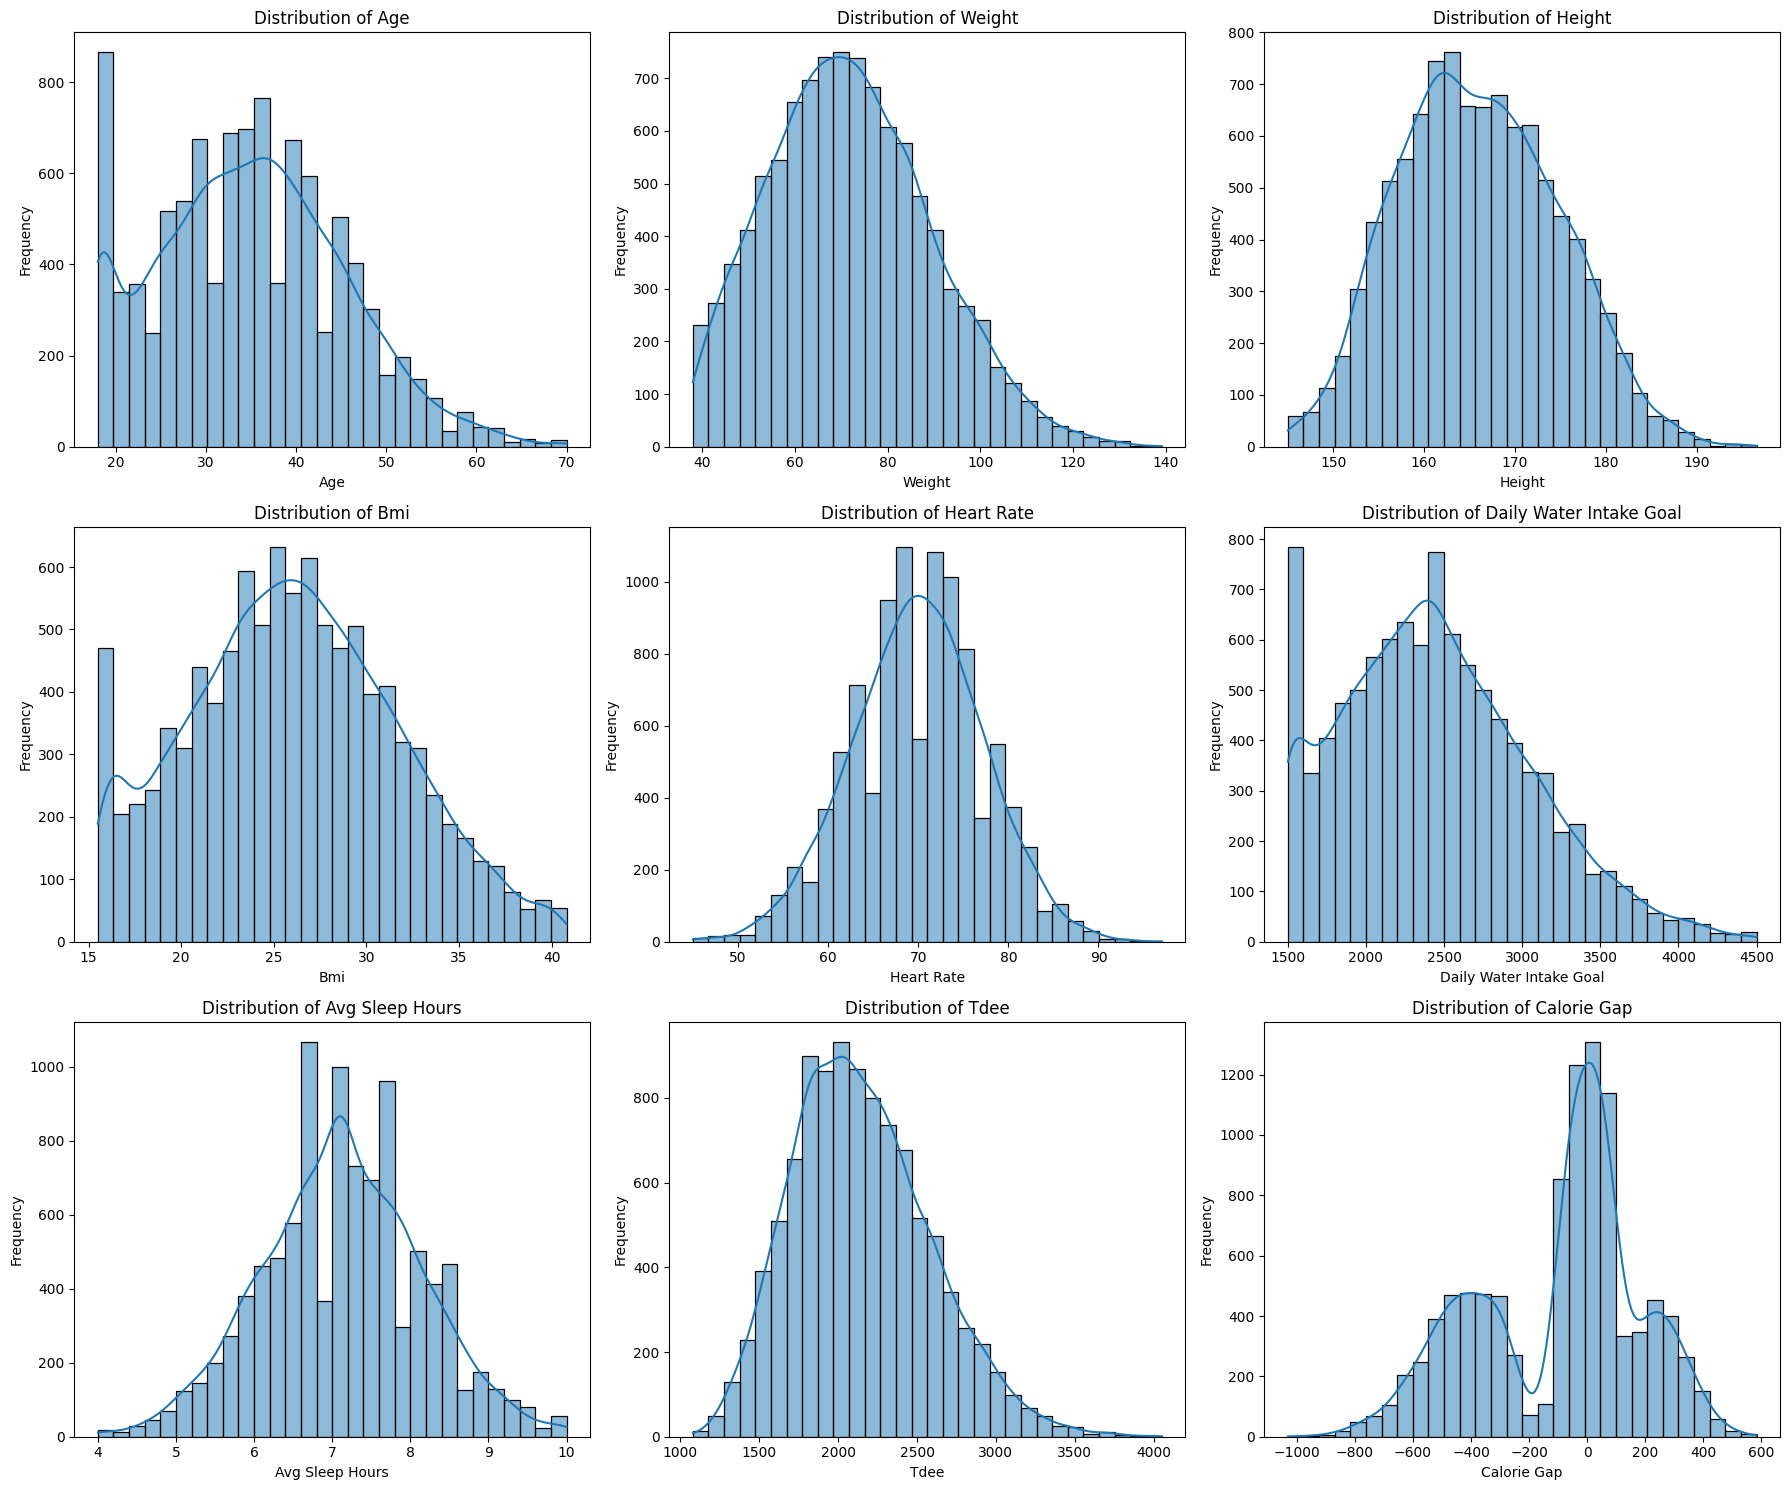

In [ ]:
# Define numerical columns for distribution plots
num_cols = ['age', 'weight', 'height', 'BMI', 'heart_rate', 'daily_water_intake_goal', 'avg_sleep_hours', 'TDEE', 'calorie_gap']

plt.figure(figsize=(18, 15))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_fe[col], kde=True, bins=30, palette='viridis')
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Kolom Fitur Kategorikal

Bagian ini menganalisis distribusi variabel-variabel kategorikal dalam dataset pengguna sintetis, mencakup `gender`, `activity_level`, `primary_goal`, `age_group`, `bmi_category`, `bp_category`, dan `sleep_quality`.

Count plot digunakan untuk memvisualisasikan frekuensi setiap kategori dalam suatu fitur, sehingga diperoleh gambaran menyeluruh mengenai komposisi demografis dan gaya hidup dari populasi pengguna yang disimulasikan. Analisis ini membantu memverifikasi bahwa proses pembangkitan data sintetis menghasilkan populasi yang cukup beragam dan realistis — menghindari ketidakseimbangan kelas yang ekstrem yang dapat berdampak negatif pada performa model.

Hasil analisis ini juga akan memunculkan pola awal yang relevan dengan pertanyaan bisnis, seperti proporsi pengguna dengan BMI di atas normal atau sebaran tujuan kesehatan utama pengguna.

/tmp/ipykernel_8533/2783768689.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_fe, palette='magma', order=df_fe[col].value_counts().index)
/tmp/ipykernel_8533/2783768689.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_fe, palette='magma', order=df_fe[col].value_counts().index)
/tmp/ipykernel_8533/2783768689.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_fe, palette='magma', order=df_fe[col].value_counts().index)
/tmp/ipykernel_8533/2783768689.py:10: FutureWarning: 

Passing `

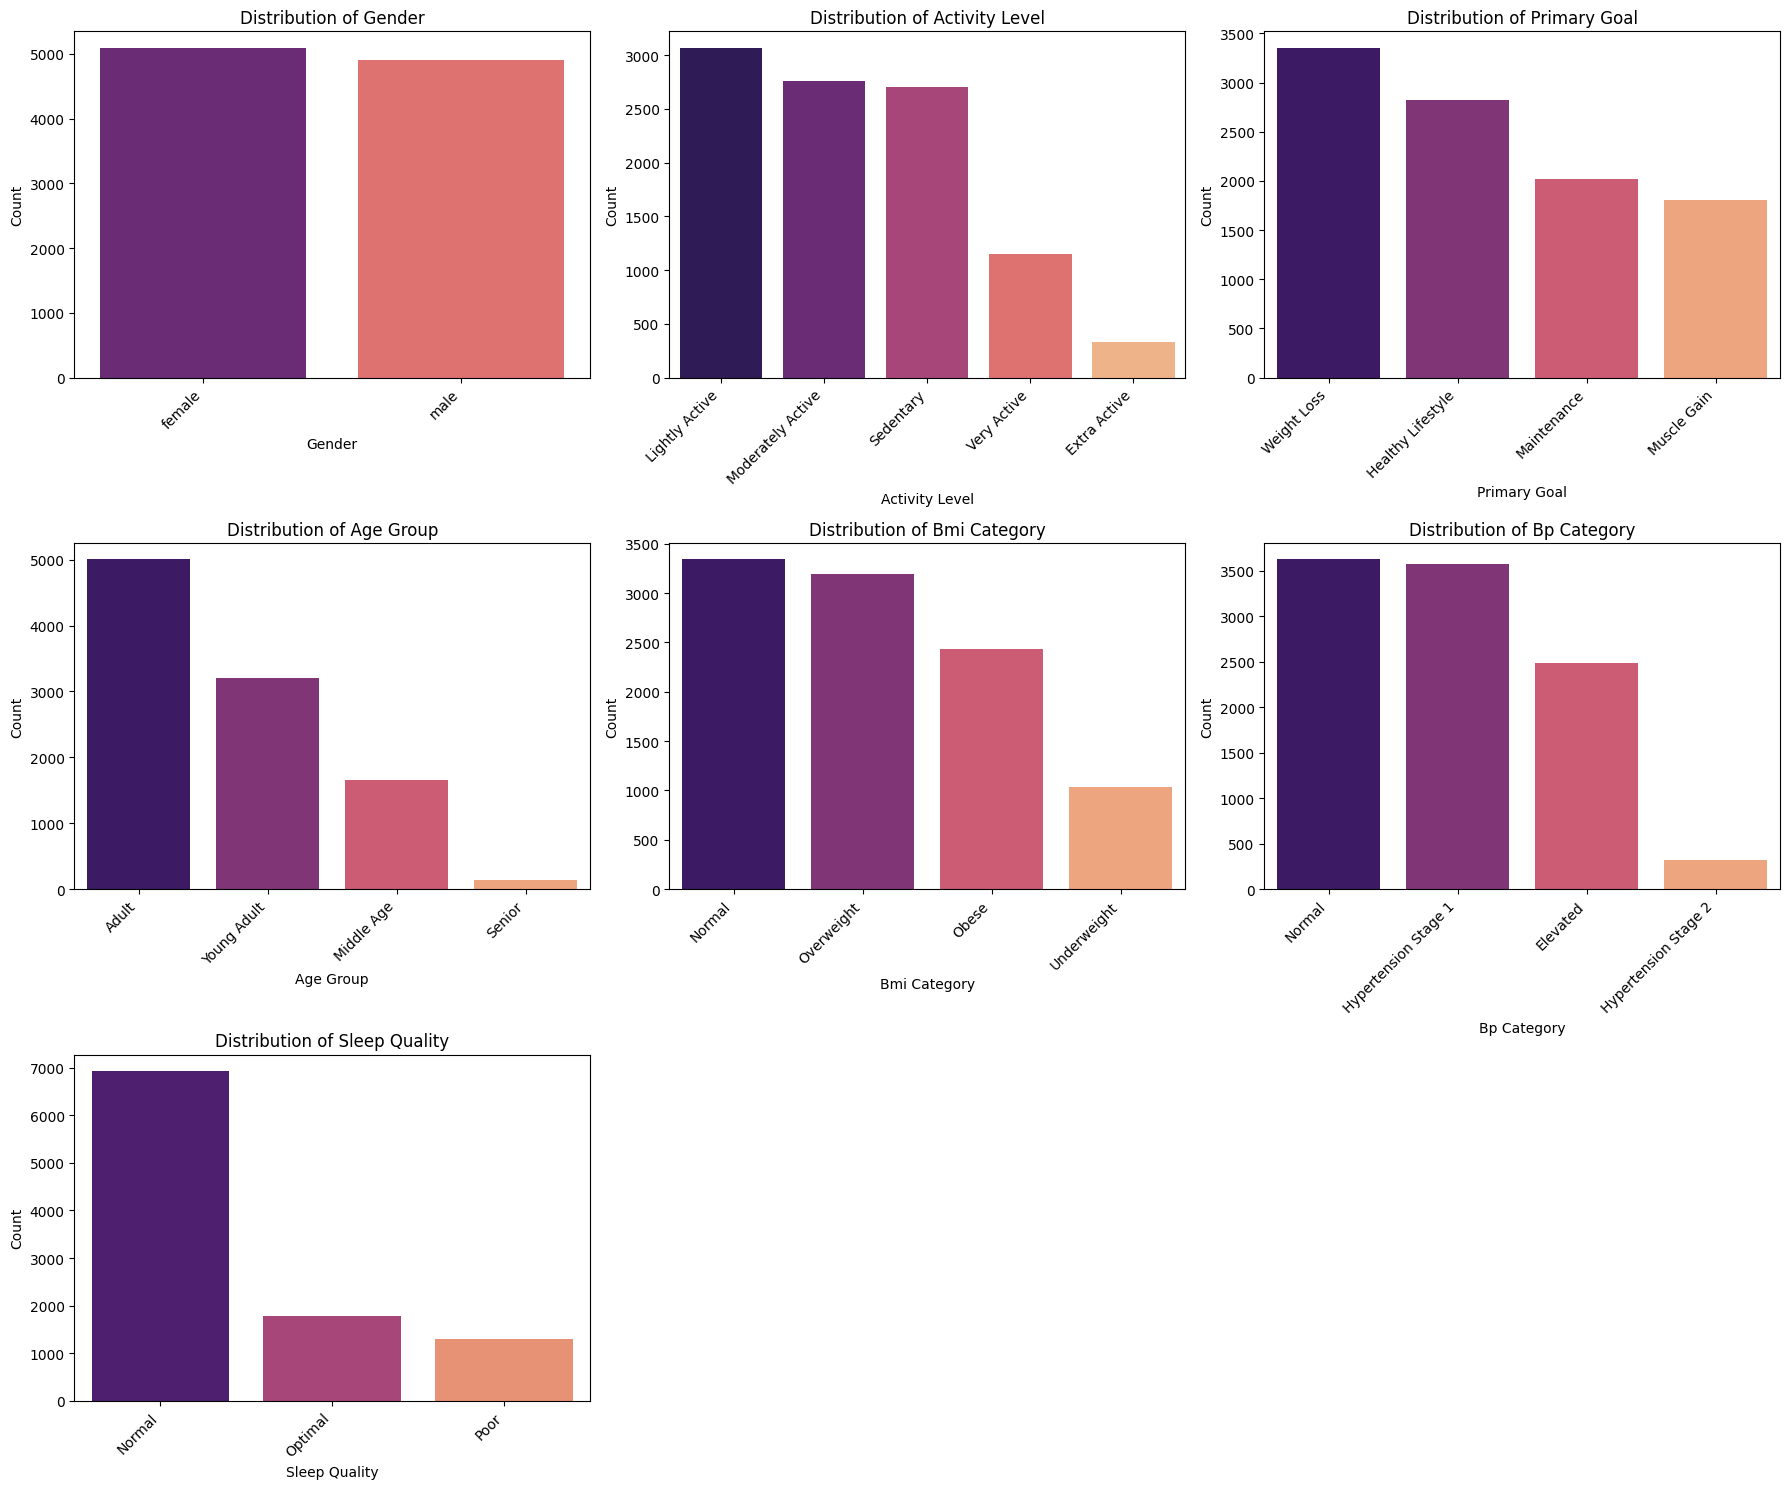

In [ ]:
# Define categorical columns for count plots (including derived ones)
cat_cols = ['gender', 'activity_level', 'primary_goal', 'age_group', 'bmi_category', 'bp_category', 'sleep_quality']

plt.figure(figsize=(18, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=col, data=df_fe, palette='magma', order=df_fe[col].value_counts().index)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Matriks Korelasi Fitur Numerik

Bagian ini melakukan analisis korelasi komprehensif terhadap seluruh fitur numerik dalam dataset pengguna yang telah melalui proses rekayasa fitur (`df_fe`), mencakup indikator biometrik, skor risiko kesehatan, variabel terkait kalori, dan metrik gaya hidup turunan.

Heatmap matriks korelasi Pearson digunakan untuk mengidentifikasi kekuatan dan arah hubungan linear antar pasangan fitur. Korelasi yang kuat — baik positif maupun negatif — dapat mengungkap fitur yang redundan, menginformasikan strategi reduksi dimensi, serta menyoroti asosiasi yang bermakna secara biologis (misalnya, hubungan yang diharapkan antara BMI, berat badan, dan skor risiko kesehatan).

Hasil analisis ini akan memandu proses seleksi fitur sebelum pelatihan model dan memastikan bahwa set fitur akhir yang digunakan untuk rekomendasi kesehatan yang dipersonalisasi bersifat informatif dan tidak redundan.

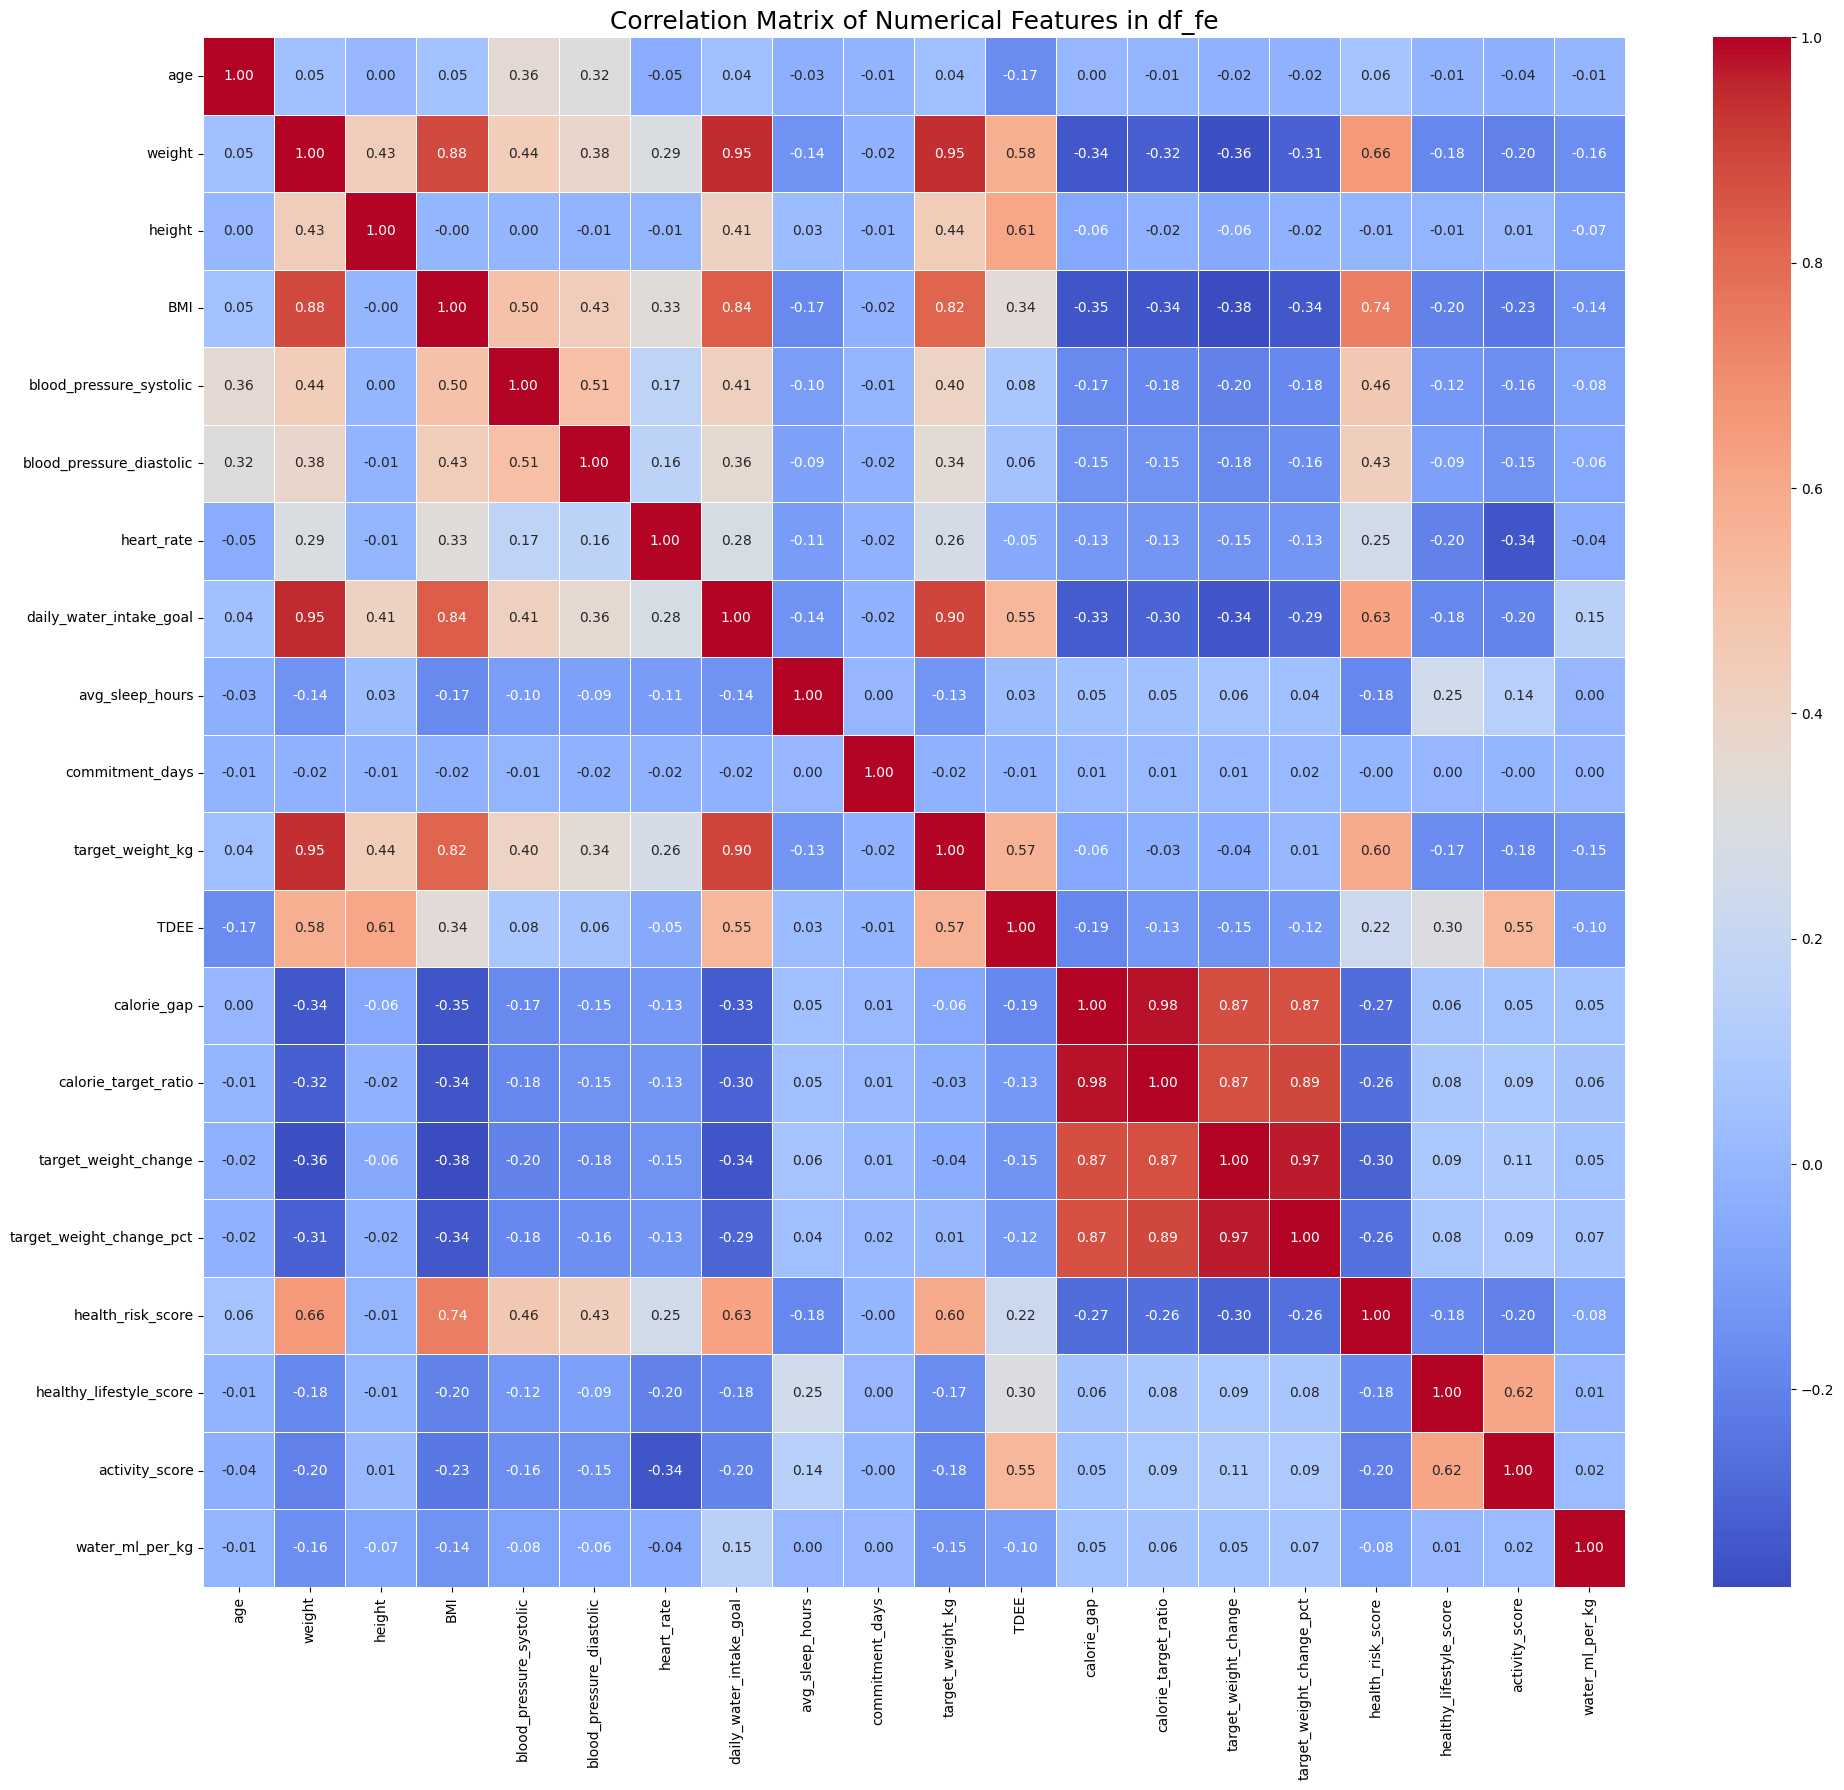

In [ ]:
# Select numerical columns for correlation analysis from df_fe
numerical_features_fe = [
    'age', 'weight', 'height', 'BMI', 'blood_pressure_systolic',
    'blood_pressure_diastolic', 'heart_rate', 'daily_water_intake_goal',
    'avg_sleep_hours', 'commitment_days', 'target_weight_kg', 'TDEE',
    'calorie_gap', 'calorie_target_ratio', 'target_weight_change',
    'target_weight_change_pct', 'health_risk_score', 'healthy_lifestyle_score',
    'activity_score', 'water_ml_per_kg'
]

# Calculate the correlation matrix
correlation_matrix_fe = df_fe[numerical_features_fe].corr()

# Plotting the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix_fe, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features in df_fe', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()